# Prerequisite.
Skip this part if you don't use Google Colab to run this file or you already have `pycountry` and `colorcet`

In [1]:
if "google.colab" in str(get_ipython()):
    !pip install pycountry
    !pip install colorcet

## A. Prepare datasets

### A.1. Import and styling

In [2]:
import requests
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")
import kagglehub
import pycountry
import colorcet
from pathlib import Path

In [3]:
# ── Style ──
PALETTE = plt.cm.tab10.colors
# PALETTE = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD",
#            "#D4537E", "#639922", "#BA7517", "#E24B4A"]
BG = "#F8F8F6"
CARD = "#FFFFFF"
MUTED = "#A9A9A9"
TEXT = "#2C2C2A"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#D3D1C7", "axes.labelcolor": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": TEXT, "grid.color": "#E8E6E0",
    "grid.linewidth": 0.5, "axes.spines.top": False,
    "axes.spines.right": False, "font.family": "sans-serif",
    "font.size": 11,
})

FIGURE_SAVE_PATH = 'original_graphs'
Path(FIGURE_SAVE_PATH).mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(f"{name}.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)

### A.2. Download datasets

In [4]:
original_path = kagglehub.dataset_download("adilshamim8/salaries-for-data-science-jobs")

In [5]:
globalai_path = kagglehub.dataset_download("mohankrishnathalla/global-ai-and-data-jobs-salary-dataset")

In [6]:
original_df = pl.read_csv(f"{original_path}/salaries.csv")
original_df

work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
i64,str,str,str,i64,str,i64,str,i64,str,str
2025,"""EX""","""FT""","""Head of Data""",348516,"""USD""",348516,"""US""",0,"""US""","""M"""
2025,"""EX""","""FT""","""Head of Data""",232344,"""USD""",232344,"""US""",0,"""US""","""M"""
2025,"""SE""","""FT""","""Data Scientist""",145400,"""USD""",145400,"""US""",0,"""US""","""M"""
2025,"""SE""","""FT""","""Data Scientist""",81600,"""USD""",81600,"""US""",0,"""US""","""M"""
2025,"""MI""","""FT""","""Engineer""",160000,"""USD""",160000,"""US""",100,"""US""","""M"""
…,…,…,…,…,…,…,…,…,…,…
2020,"""SE""","""FT""","""Data Scientist""",412000,"""USD""",412000,"""US""",100,"""US""","""L"""
2021,"""MI""","""FT""","""Principal Data Scientist""",151000,"""USD""",151000,"""US""",100,"""US""","""L"""
2020,"""EN""","""FT""","""Data Scientist""",105000,"""USD""",105000,"""US""",100,"""US""","""S"""


In [7]:
globalai_df = pl.read_csv(f"{globalai_path}/global_ai_jobs.csv")
globalai_df

id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
i64,str,str,str,str,i64,i64,i64,str,str,str,i64,i64,str,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64
1,"""UAE""","""Machine Learning Engineer""","""Reinforcement Learning""","""Entry""",0,66465,5395,"""Master""","""Automotive""","""Small""",7,2020,"""Remote""",44.7,3.67,10,52.765351,0.404,91,3.3,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
2,"""USA""","""AI Engineer""","""LLM""","""Entry""",1,75507,11713,"""Bootcamp""","""Retail""","""Small""",3,2021,"""Onsite""",48.9,4.26,27,53.11458,0.387,71,4.39,62.14,13,75.8,28.4,27,54,29,69,60,51,15,58,0.87,67
3,"""Brazil""","""Research Scientist""","""Analytics""","""Entry""",0,41660,5268,"""PhD""","""Healthcare""","""Large""",3,2020,"""Remote""",46.8,4.78,10,76.395263,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
4,"""India""","""Software Engineer AI""","""Computer Vision""","""Senior""",6,43268,7975,"""Diploma""","""Tech""","""Large""",2,2026,"""Onsite""",52.2,4.34,23,59.340199,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
5,"""Germany""","""Machine Learning Engineer""","""Computer Vision""","""Entry""",0,69119,4758,"""Master""","""Retail""","""Medium""",2,2021,"""Hybrid""",46.7,4.49,17,72.301128,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
89996,"""Germany""","""Research Scientist""","""Forecasting""","""Lead""",14,147903,30957,"""Bootcamp""","""Energy""","""Enterprise""",7,2023,"""Remote""",40.2,4.08,19,59.277544,0.138,75,7.83,47.81,7,78.42,16.9,27,4,71,85,56,77,14,17,2.46,85
89997,"""Germany""","""Machine Learning Engineer""","""NLP""","""Mid""",2,81608,7991,"""Bootcamp""","""Gaming""","""Startup""",6,2026,"""Hybrid""",50.7,3.4,33,52.450137,0.196,66,0.72,68.01,10,93.15,26.7,19,46,65,71,34,62,61,88,1.38,68
89998,"""Singapore""","""Computer Vision Engineer""","""Computer Vision""","""Mid""",5,91473,17876,"""Bootcamp""","""Energy""","""Enterprise""",5,2020,"""Onsite""",45.6,4.48,16,57.170626,0.263,65,9.02,45.3,13,83.17,26.3,27,89,6,72,75,77,12,28,2.14,71


## B. Data validation & cleaning

### B.1. Validation

In [8]:
def currency_formatter(x, pos=None):
    if x >= 1_000_000:
        return f'${x*1e-6:1.0f}M'
    elif x >= 1_000:
        return f'${x*1e-3:1.0f}k'
    return f'${x:1.0f}'

In [9]:
def row_count_by_year(df, year_col="year", dataset_name=None, save_path=None):
    year_counts = (df.group_by(year_col)
                  .agg(pl.len().alias("count"))
                  .sort(year_col))
    
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(BG)
    xs = year_counts[year_col].to_list()
    ys = year_counts["count"].to_list()
    ax.set_ylim(0, max(ys) * 1.1)
    
    bars = ax.bar(xs, ys, color=PALETTE[2], width=0.55)
    
    ax.set_xlabel("Year")
    ax.set_ylabel("Row count")
    ax.set_title("Dataset rows per year", fontsize=14, fontweight="bold", pad=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
    for bar, v in zip(bars, ys):
        ax.annotate(
            f"{v:,}",
            xy=(bar.get_x() + bar.get_width() / 2, v),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            color=PALETTE[7],
        )
      
    plt.tight_layout()
    
    if save_path:
      save(fig, f"{save_path}/0_rows_per_year_{dataset_name}" if dataset_name else f"{save_path}/0_rows_per_year")
    else:
      plt.show()

In [10]:
def stacked_row_count_by_year(df1, df2, year_col="year", labels=("Dataset 1", "Dataset 2"), dataset_name=None, save_path=None):
    year_counts = (
        df1.group_by(year_col)
        .agg(pl.len().alias("count1"))
        .join(
            df2.group_by(year_col)
            .agg(pl.len().alias("count2")),
            on=year_col,
            how="full",
        )
        .fill_null(0)
        .sort(year_col)
    )

    xs = year_counts[year_col].to_list()
    y1 = year_counts["count1"].to_list()
    y2 = year_counts["count2"].to_list()
    totals = [a + b for a, b in zip(y1, y2)]

    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(BG)

    ax.set_ylim(0, max(totals) * 1.1)

    bars1 = ax.bar(xs, y1, color=PALETTE[2], width=0.55, label=labels[0])
    bars2 = ax.bar(xs, y2, bottom=y1, color=PALETTE[1], width=0.55, label=labels[1])

    ax.set_xlabel("Year")
    ax.set_ylabel("Row count")
    ax.set_title("Dataset rows per year", fontsize=14, fontweight="bold", pad=12)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))

    for bar, total in zip(bars1, totals):
        ax.annotate(
            f"{total:,}",
            xy=(bar.get_x() + bar.get_width() / 2, total),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            color=PALETTE[7],
        )

    ax.legend()

    plt.tight_layout()

    if save_path:
        save(fig, f"{save_path}/0_rows_per_year_{dataset_name}" if dataset_name else f"{save_path}/0_rows_per_year")
    else:
        plt.show()

    plt.close(fig)

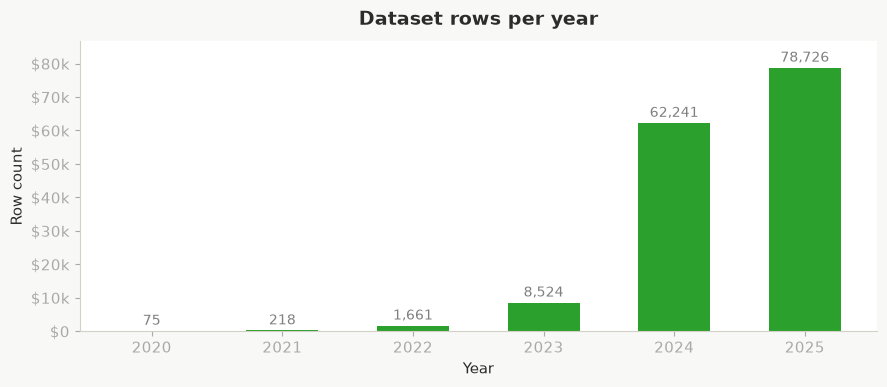

In [11]:
row_count_by_year(original_df, "work_year")

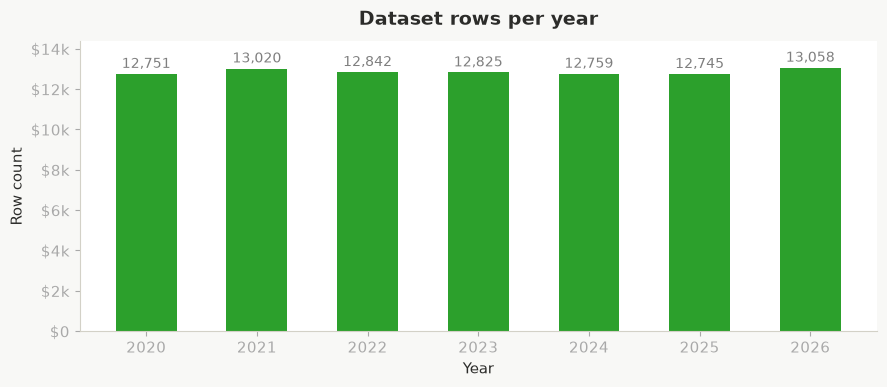

In [12]:
row_count_by_year(globalai_df)

In [13]:
def show_salary_lowest_highest(df, salary_col_name, n=20):
  sorted_salary = df.sort(salary_col_name, descending=True).select(salary_col_name)

  print(f"  Lowest {n}:")
  print(sorted_salary.tail(n)[salary_col_name].to_list())
  print(f"\n  Highest {n}:")
  print(sorted_salary.head(n)[salary_col_name].to_list())


In [14]:
def show_salary_outliers(df, salary_col_name):
  salaries = df[salary_col_name]

  q1 = salaries.quantile(0.25)
  q3 = salaries.quantile(0.75)
  iqr = q3 - q1

  lower = (salaries < q1 - 1.5 * iqr).sum()
  upper = (salaries > q3 + 1.5 * iqr).sum()

  print(f"{lower} lower outliers (< {q1 - 1.5 * iqr})")
  print(f"{upper} upper outliers (> {q3 + 1.5 * iqr})")
  print(f"Total {lower + upper}")

In [15]:
def validate(df, salary_col_name):
  # 1. Data types + unique counts
  print("1. Schema & unique counts per column:")
  for col in df.columns:
      dtype  = df[col].dtype
      n_null = df[col].null_count()
      n_uniq = df[col].n_unique()
      print(f"  {col:<25} dtype={str(dtype):<12} "
            f"nulls={n_null:<6} unique={n_uniq}")

  # 2. Missing values table
  null_df = (
      df.select([pl.col(c).null_count().alias(c) for c in df.columns])
        .unpivot(variable_name="column", value_name="nulls")
        .with_columns((pl.col("nulls") / len(df) * 100).alias("pct"))
        .sort("nulls", descending=True)
  )
  print("\n2. Missing values summary:")
  print(null_df)

  # 3. Outliers
  print("\n3. Outliers:")
  show_salary_outliers(df, salary_col_name)

  # 4. Lowests and highests
  print("\n4. Lowests and highests:")
  show_salary_lowest_highest(df, salary_col_name)

In [16]:
validate(original_df, "salary_in_usd")

1. Schema & unique counts per column:
  work_year                 dtype=Int64        nulls=0      unique=6
  experience_level          dtype=String       nulls=0      unique=4
  employment_type           dtype=String       nulls=0      unique=4
  job_title                 dtype=String       nulls=0      unique=422
  salary                    dtype=Int64        nulls=0      unique=12308
  salary_currency           dtype=String       nulls=0      unique=26
  salary_in_usd             dtype=Int64        nulls=0      unique=13580
  employee_residence        dtype=String       nulls=0      unique=104
  remote_ratio              dtype=Int64        nulls=0      unique=3
  company_location          dtype=String       nulls=0      unique=97
  company_size              dtype=String       nulls=0      unique=3

2. Missing values summary:
shape: (11, 3)
┌────────────────────┬───────┬─────┐
│ column             ┆ nulls ┆ pct │
│ ---                ┆ ---   ┆ --- │
│ str                ┆ u32   ┆ f64 

In [17]:
validate(globalai_df, "salary_usd")

1. Schema & unique counts per column:
  id                        dtype=Int64        nulls=0      unique=90000
  country                   dtype=String       nulls=0      unique=12
  job_role                  dtype=String       nulls=0      unique=8
  ai_specialization         dtype=String       nulls=0      unique=8
  experience_level          dtype=String       nulls=0      unique=4
  experience_years          dtype=Int64        nulls=0      unique=20
  salary_usd                dtype=Int64        nulls=0      unique=65976
  bonus_usd                 dtype=Int64        nulls=0      unique=27544
  education_required        dtype=String       nulls=0      unique=5
  industry                  dtype=String       nulls=0      unique=10
  company_size              dtype=String       nulls=0      unique=5
  interview_rounds          dtype=Int64        nulls=0      unique=6
  year                      dtype=Int64        nulls=0      unique=7
  work_mode                 dtype=String       nul

### B.2. Cleaning & Merging

In [18]:
def country_numeric_from_code(code):
    if code is None:
        return None
    try:
        country = pycountry.countries.get(alpha_2=code)
        if country:
            return int(country.numeric)
    except:
        return None
    return None


def country_numeric_from_name(name):
    if name is None:
        return None

    try:
        result = pycountry.countries.search_fuzzy(name)[0]
        return int(result.numeric)

    except:
        return None


remote_map = {
    0: "Onsite",
    50: "Hybrid",
    100: "Remote"
}

company_size_map = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

experience_level_map = {
    "SE": "Senior",
    "MI": "Mid",
    "EN": "Entry",
    "EX": "Executive"
}

In [19]:
countries = (
    globalai_df
    .select("country")
    .unique()
    .to_series()
    .to_list()
)

# build dictionary once
country_name_map = {
    c: country_numeric_from_name(c)
    for c in countries
}

In [20]:
def country_name_from_numeric(code):
    if code is None:
        return None
    try:
        return pycountry.countries.get(
            numeric=str(code).zfill(3)
        ).name
    except:
        return None

In [21]:
original_mapped_df = (
    original_df
    .unique(subset=[c for c in original_df.columns if c not in ["salary_in_usd"]]) # Remove duplicates
    .select([
        pl.col("work_year").alias("year"),
        "job_title",
        pl.col("salary_in_usd").alias("salary_usd"),
        "experience_level",
        # pl.col("employee_residence").alias("employee_location"),
        pl.col("company_location").alias("company_location_code"),
        pl.col("remote_ratio").alias("work_mode"),
        "company_size"
    ])
    .with_columns([
        # pl.col("employee_location").map_elements(
        #     country_numeric_from_code,
        #     return_dtype=pl.Int64
        # ),
        pl.col("company_location_code").map_elements(
            country_numeric_from_code,
            return_dtype=pl.Int64
        ),
        pl.col("work_mode").replace_strict(remote_map),
        pl.col("company_size").replace(company_size_map),
        pl.col("experience_level").replace(experience_level_map),
    ])
)

In [22]:
globalai_mapped_df = (
    globalai_df
    .unique(subset=[c for c in globalai_df.columns if c not in ["salary_usd"]]) # Remove duplicates
    .filter((pl.col("year") >= 2020) & (pl.col("year") <= 2022))
    .select([
        "year",
        pl.col("job_role").alias("job_title"),
        pl.col("salary_usd"),
        "experience_level",
        # pl.col("country").alias("employee_location"),
        pl.col("country").alias("company_location_code"),
        "work_mode",
        "company_size"
    ])
    .with_columns([
        # pl.col("employee_location").map_elements(
        #     country_numeric_from_name,
        #     return_dtype=pl.Int64
        # ),
        pl.col("company_location_code").replace_strict(country_name_map),
    ])
)

In [23]:
original_mapped_df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size
i64,str,i64,str,i64,str,str
2025,"""QA Engineer""",38000,"""Mid""",840,"""Onsite""","""Medium"""
2024,"""Machine Learning Engineer""",117200,"""Mid""",840,"""Onsite""","""Medium"""
2025,"""Analytics Engineer""",220000,"""Senior""",840,"""Onsite""","""Medium"""
2024,"""Software Engineer""",148000,"""Mid""",840,"""Onsite""","""Medium"""
2024,"""Cloud Engineer""",46400,"""Mid""",440,"""Onsite""","""Medium"""
…,…,…,…,…,…,…
2024,"""Associate""",126800,"""Mid""",840,"""Remote""","""Medium"""
2025,"""Systems Engineer""",185000,"""Senior""",840,"""Remote""","""Medium"""
2024,"""Consultant""",80700,"""Senior""",840,"""Onsite""","""Medium"""


In [24]:
globalai_mapped_df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size
i64,str,i64,str,i64,str,str
2021,"""Data Scientist""",71613,"""Entry""",826,"""Onsite""","""Medium"""
2021,"""Machine Learning Engineer""",72518,"""Entry""",826,"""Hybrid""","""Large"""
2020,"""Computer Vision Engineer""",55083,"""Entry""",276,"""Remote""","""Medium"""
2022,"""AI Engineer""",54381,"""Entry""",528,"""Remote""","""Small"""
2020,"""Data Analyst""",102465,"""Lead""",528,"""Onsite""","""Large"""
…,…,…,…,…,…,…
2022,"""Data Analyst""",29333,"""Entry""",76,"""Onsite""","""Enterprise"""
2021,"""Research Scientist""",159307,"""Senior""",36,"""Onsite""","""Enterprise"""
2022,"""Research Scientist""",30487,"""Entry""",76,"""Hybrid""","""Startup"""


In [25]:
concat_df = pl.concat(
    [
        original_mapped_df,
        globalai_mapped_df
    ],
    how="vertical"
)

df = concat_df.with_columns(
    pl.col("company_location_code").map_elements(
        country_name_from_numeric,
        return_dtype=pl.String
    ).alias("company_location")
)
df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size,company_location
i64,str,i64,str,i64,str,str,str
2025,"""QA Engineer""",38000,"""Mid""",840,"""Onsite""","""Medium""","""United States"""
2024,"""Machine Learning Engineer""",117200,"""Mid""",840,"""Onsite""","""Medium""","""United States"""
2025,"""Analytics Engineer""",220000,"""Senior""",840,"""Onsite""","""Medium""","""United States"""
2024,"""Software Engineer""",148000,"""Mid""",840,"""Onsite""","""Medium""","""United States"""
2024,"""Cloud Engineer""",46400,"""Mid""",440,"""Onsite""","""Medium""","""Lithuania"""
…,…,…,…,…,…,…,…
2022,"""Data Analyst""",29333,"""Entry""",76,"""Onsite""","""Enterprise""","""Brazil"""
2021,"""Research Scientist""",159307,"""Senior""",36,"""Onsite""","""Enterprise""","""Australia"""
2022,"""Research Scientist""",30487,"""Entry""",76,"""Hybrid""","""Startup""","""Brazil"""


In [26]:
values = (df.select(pl.col("job_title")).unique("job_title").sort(by="job_title").to_series().to_list())


print("\n".join(map(str, values)))

AI Architect
AI Content Writer
AI Data Engineer
AI Data Scientist
AI Developer
AI Engineer
AI Engineering Lead
AI Engineering Manager
AI Governance Lead
AI Governance Specialist
AI Lead
AI Machine Learning Engineer
AI Product Lead
AI Product Manager
AI Product Owner
AI Product Specialist
AI Programmer
AI Research Engineer
AI Research Scientist
AI Researcher
AI Scientist
AI Software Development Engineer
AI Software Engineer
AI Solution Architect
AI Solution Director
AI Solutions Consultant
AI Solutions Lead
AI Solutions Specialist
AI Specialist
AI Strategist
AI Tech Lead
AIRS Solutions Specialist
AWS Data Architect
Account Executive
Actuarial Analyst
Actuary
Admin & Data Analyst
Advanced Analytics Manager
Advanced Data Analyst
Algorithm Developer
Alternance
Analyst
Analytics Analyst
Analytics Engineer
Analytics Engineering Manager
Analytics Lead
Analytics Manager
Analytics Specialist
Application Developer
Applied AI ML Lead
Applied Data Scientist
Applied Machine Learning Engineer
Applie

In [27]:
# =========================
# Exact manual mapping
# =========================

manual = {

    # -------------------------
    # AI
    # -------------------------
    "AI Architect": "AI Engineer",
    "AI Lead": "AI Engineer",
    "AI Specialist": "AI Engineer",
    "AI Strategist": "AI Engineer",
    "AI Tech Lead": "AI Engineer",
    "AI Solutions Lead": "AI Engineer",
    "AI Solutions Specialist": "AI Engineer",
    "AIRS Solutions Specialist": "AI Engineer",

    "Artificial Intelligence Engineer": "AI Engineer",

    "AI Solution Architect": "Solution Architect",
    "AI Solution Director": "Solution Architect",
    "AI Solutions Consultant": "Solution Architect",

    "AI Scientist": "Data Scientist",
    "Applied AI ML Lead": "Machine Learning Engineer",

    "AI Software Development Engineer": "AI Engineer",
    "AI Software Engineer": "AI Engineer",
    "Software Engineer AI": "AI Engineer",

    "Lead AI Engineer": "AI Engineer",


    # -------------------------
    # Product
    # -------------------------
    "AI Product Specialist": "Product Manager",

    "Product Specialist": "Product Manager",
    "Product Designer": "Product Manager",

    "Data Product Analyst": "Product Manager",
    "Data Product Lead": "Product Manager",
    "Data Product Manager": "Product Manager",
    "Data Product Owner": "Product Manager",

    "Technical Project Manager": "Product Manager",


    # -------------------------
    # Data Analyst
    # -------------------------
    "Actuarial Analyst": "Quantitative Analyst",

    "Advanced Analytics Manager": "Data Analyst",
    "Analytics Lead": "Data Analyst",
    "Analytics Manager": "Data Analyst",
    "Analytics Specialist": "Data Analyst",

    "BI Analyst": "Data Analyst",
    "Business Intelligence Analyst": "Data Analyst",
    "Business Intelligence Lead": "Data Analyst",
    "Business Intelligence Manager": "Data Analyst",

    "Data Analist": "Data Analyst",
    "Data Analysis": "Data Analyst",
    "Data Analysis Specialist": "Data Analyst",

    "Data Specialist": "Data Analyst",

    "Data Strategist": "Data Analyst",
    "Data Strategy Lead": "Data Analyst",
    "Data Strategy Manager": "Data Analyst",
    "Data Team Lead": "Data Analyst",


    # -------------------------
    # Data Engineering
    # -------------------------
    "Data Integration Analyst": "Data Analyst",
    "Data Integration Engineer": "Data Engineer",
    "Data Integration Specialist": "Data Engineer",

    "Data Operations": "Data Engineer",
    "Data Operations Analyst": "Data Analyst",
    "Data Operations Engineer": "Data Engineer",
    "Data Operations Specialist": "Data Engineer",

    "Scala Spark Developer": "Data Engineer",


    # -------------------------
    # Data Management
    # -------------------------
    "Data Management": "Data Manager",

    "Data Management Analyst": "Data Manager",
    "Data Management Associate": "Data Manager",
    "Data Management Consultant": "Data Manager",
    "Data Management Coordinator": "Data Manager",
    "Data Management Expert": "Data Manager",
    "Data Management Lead": "Data Manager",
    "Data Management Manager": "Data Manager",
    "Data Management Officer": "Data Manager",
    "Data Management Professional": "Data Manager",
    "Data Management Specialist": "Data Manager",
    "Data Management Technician": "Data Manager",


    # -------------------------
    # Research
    # -------------------------
    "Research Analyst": "Researcher (General)",
    "Research Assistant": "Researcher (General)",
    "Research Associate": "Researcher (General)",
    "Research Fellow": "Researcher (General)",
    "Research Professional": "Researcher (General)",
    "Research Specialist": "Researcher (General)",
    "Research Team Lead": "Researcher (General)",

    "Post Doctoral Fellow": "Researcher (General)",
    "Postdoctoral Fellow": "Researcher (General)",
    "Postdoctoral Research Fellow": "Researcher (General)",
    "Postdoctoral Scholar": "Researcher (General)",

    "Principal Scientist": "Research Scientist",

    "Machine Learning Researcher": "Research Scientist",
    "Machine Learning Research Engineer": "Research Engineer",

    "Applied Machine Learning Scientist": "Data Scientist",
    "Machine Learning Scientist": "Data Scientist",
    "Deep Learning Researcher": "Research Scientist",


    # -------------------------
    # Engineering
    # -------------------------
    "Engineer": "Software Engineer",

    "Automation Engineer": "Software Engineer",
    "Forward Deployed Engineer": "Software Engineer",

    "Lead Engineer": "Software Engineer",
    "Principal Engineer": "Software Engineer",

    "Tech Lead": "Software Engineer",
    "Technical Lead": "Software Engineer",

    "Member of Technical Staff": "Software Engineer",


    # -------------------------
    # Architecture
    # -------------------------
    "Architect": "Architect",
    "Technical Architect": "Architect",

    "AWS Data Architect": "Data Architect",
    "Cloud Data Architect": "Data Architect",
    "IT Enterprise Data Architect": "Data Architect",
    "Cloud Architect": "Architect",


    # -------------------------
    # ML
    # -------------------------
    "ML Scientist": "Machine Learning Engineer",

    "Lead Machine Learning Engineer": "Machine Learning Engineer",
    "Machine Learning Manager": "Machine Learning Engineer",


    # -------------------------
    # Vision
    # -------------------------
    "Machine Vision Engineer": "Computer Vision Engineer",


    # -------------------------
    # Management
    # -------------------------
    "AI Engineering Manager": "Engineering Manager",
    "Analytics Engineering Manager": "Engineering Manager",


    # -------------------------
    # Software
    # -------------------------
    "Developer": "Software Engineer",
    "Backend Developer": "Software Engineer",
    "Frontend Engineer": "Software Engineer",
    "Full Stack Developer": "Software Engineer",
    "Web Developer": "Software Engineer",

    "Python Developer": "Software Engineer",
    "Java Developer": "Software Engineer",


    # -------------------------
    # Other
    # -------------------------
    "Network Engineer": "Network Engineer",
    "System Engineer": "System Engineer",
    "Systems Engineer": "System Engineer",
}



# =========================
# Keyword rules
# order matters
# =========================

rules = {


    # Research first
    "Research Engineer": [
        "research engineer"
    ],

    "Research Scientist": [
        "research scientist",
        "researcher"
    ],


    # Solution before software
    "Solution Architect": [
        "solution",
        "solutions"
    ],


    # AI
    "AI Engineer": [
        "ai engineer",
        "ai developer",
        "artificial intelligence",
        "genai",
        "chatbot",
        "conversational ai"
    ],


    # ML
    "Machine Learning Engineer": [
        "machine learning",
        "deep learning",
        "ml engineer",
        "mlops"
    ],


    "NLP Engineer": [
        "nlp",
        "llm"
    ],


    # Data science
    "Data Scientist": [
        "data scientist",
        "applied scientist",
        "decision scientist",
        "computational scientist"
    ],


    # Data engineer
    "Data Engineer": [
        "data engineer",
        "etl",
        "dataops",
        "pipeline",
        "spark",
        "analytics engineer"
    ],


    # Data analyst
    "Data Analyst": [
        "data analyst",
        "business analyst",
        "analytics analyst",
        "reporting analyst",
        "insight analyst"
    ],


    "Data Architect": [
        "data architect",
        "data modeler"
    ],


    "Data Governance": [
        "governance",
        "quality",
        "steward"
    ],


    "Data Manager": [
        "data management",
        "data manager",
        "master data"
    ],


    "Database Engineer": [
        "database administrator",
        "database engineer"
    ],


    # Software
    "Software Architect": [
        "software architect"
    ],

    "Software Engineer": [
        "software",
        "developer",
        "programmer",
        "backend",
        "frontend",
        "full stack",
        "fullstack",
        "application",
        "python",
        "java",
        "scala"
    ],


    "Cloud Engineer": [
        "cloud",
        "infrastructure",
        "platform"
    ],


    "DevOps Engineer": [
        "devops",
        "site reliability",
        "sre"
    ],


    "BI Developer": [
        "power bi",
        "tableau"
    ],


    "Data Visualization": [
        "visualization"
    ],


    "Consultant": [
        "consultant"
    ],


    "Sales": [
        "sales",
        "account executive"
    ],


    "QA Engineer": [
        "qa"
    ],


    "Technical Writer": [
        "writer",
        "copywriter"
    ],


    "Support Engineer": [
        "support"
    ],


    "Robotics Engineer": [
        "robotics"
    ],


    "Computer Vision Engineer": [
        "computer vision"
    ],


    "Quantitative Analyst": [
        "quant",
        "actuary"
    ],


    "Risk Analyst": [
        "risk"
    ],


    "Engineering Manager": [
        "engineering manager"
    ],


    "Director": [
        "director",
        "head of"
    ]
}

# =========================
# Normalize function
# =========================

def normalize_role(role):
    if role in manual:
        return manual[role]

    if role is None:
        return "Other"

    role = role.lower()
    for target, keywords in rules.items():
        for keyword in keywords:
            if keyword in role:
                return target

    return "Other"

df = df.with_columns(
    pl.col("job_title")
    .map_elements(
        normalize_role,
        return_dtype=pl.String
    )
    .alias("general_role")
)

#### Double-check the mapping

In [28]:
rows = (
    df.select(["job_title", "general_role"])
      .unique()
      .sort("job_title")
      .to_dicts()
)

print("\n".join(f"{r['job_title']} - {r['general_role']}" for r in rows))


AI Architect - AI Engineer
AI Content Writer - Technical Writer
AI Data Engineer - Data Engineer
AI Data Scientist - Data Scientist
AI Developer - AI Engineer
AI Engineer - AI Engineer
AI Engineering Lead - AI Engineer
AI Engineering Manager - Engineering Manager
AI Governance Lead - Data Governance
AI Governance Specialist - Data Governance
AI Lead - AI Engineer
AI Machine Learning Engineer - Machine Learning Engineer
AI Product Lead - Other
AI Product Manager - Other
AI Product Owner - Other
AI Product Specialist - Product Manager
AI Programmer - Software Engineer
AI Research Engineer - Research Engineer
AI Research Scientist - Research Scientist
AI Researcher - Research Scientist
AI Scientist - Data Scientist
AI Software Development Engineer - AI Engineer
AI Software Engineer - AI Engineer
AI Solution Architect - Solution Architect
AI Solution Director - Solution Architect
AI Solutions Consultant - Solution Architect
AI Solutions Lead - AI Engineer
AI Solutions Specialist - AI Engin

In [29]:
other = df.filter(pl.col("general_role") == "Other")
unique_other = other.unique("job_title").height
total_other = other.height

print(f"Total other: {total_other}. Unique other: {unique_other}")

Total other: 11651. Unique other: 79


In [30]:
Path("data").mkdir(parents=True, exist_ok=True)

In [31]:
df.write_csv("data/salary_cleaned.csv")

### B.3. Check final data quality

In [32]:
validate(df, "salary_usd")

1. Schema & unique counts per column:
  year                      dtype=Int64        nulls=0      unique=6
  job_title                 dtype=String       nulls=0      unique=423
  salary_usd                dtype=Int64        nulls=0      unique=44495
  experience_level          dtype=String       nulls=0      unique=5
  company_location_code     dtype=Int64        nulls=2      unique=97
  work_mode                 dtype=String       nulls=0      unique=3
  company_size              dtype=String       nulls=0      unique=5
  company_location          dtype=String       nulls=2      unique=97
  general_role              dtype=String       nulls=0      unique=36

2. Missing values summary:
shape: (9, 3)
┌───────────────────────┬───────┬─────────┐
│ column                ┆ nulls ┆ pct     │
│ ---                   ┆ ---   ┆ ---     │
│ str                   ┆ u32   ┆ f64     │
╞═══════════════════════╪═══════╪═════════╡
│ company_location_code ┆ 2     ┆ 0.00181 │
│ company_location      ┆ 

In [33]:
df.filter(pl.col("company_location").is_null())

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size,company_location,general_role
i64,str,i64,str,i64,str,str,str,str
2025,"""Software Engineer""",31578,"""Mid""",null,"""Remote""","""Medium""",null,"""Software Engineer"""
2025,"""Software Engineer""",50526,"""Mid""",null,"""Remote""","""Medium""",null,"""Software Engineer"""


In [34]:
globalai_df.filter(pl.col("salary_usd").is_in([50526, 31578]))

id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
i64,str,str,str,str,i64,i64,i64,str,str,str,i64,i64,str,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64
78604,"""India""","""Data Scientist""","""Reinforcement Learning""","""Senior""",9,50526,3543,"""Diploma""","""Retail""","""Medium""",2,2025,"""Onsite""",44.2,4.79,25,52.728843,0.018,64,6.5,84.03,9,75.44,34.0,11,54,75,99,63,73,27,34,0.76,83
86920,"""India""","""Data Analyst""","""LLM""","""Mid""",5,31578,2409,"""Bootcamp""","""Gaming""","""Startup""",7,2020,"""Onsite""",52.9,3.66,13,65.036635,0.236,58,3.17,63.35,14,79.32,21.1,25,93,69,52,45,46,51,42,1.05,58


In [35]:
original_df.filter(pl.col("salary_in_usd").is_in([50526, 31578]) & (pl.col("experience_level") == "MI") & (pl.col("remote_ratio") == 100) & (pl.col("company_size") == "M"))

work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
i64,str,str,str,i64,str,i64,str,i64,str,str
2025,"""MI""","""FT""","""Research Scientist""",30000,"""EUR""",31578,"""GR""",100,"""GR""","""M"""
2025,"""MI""","""FT""","""Data Scientist""",48000,"""EUR""",50526,"""ES""",100,"""ES""","""M"""
2025,"""MI""","""FT""","""Software Engineer""",48000,"""EUR""",50526,"""XK""",100,"""XK""","""M"""
2025,"""MI""","""FT""","""Software Engineer""",30000,"""EUR""",31578,"""XK""",100,"""XK""","""M"""


----> Missing country is Kosovo (XK), with no official ISO code

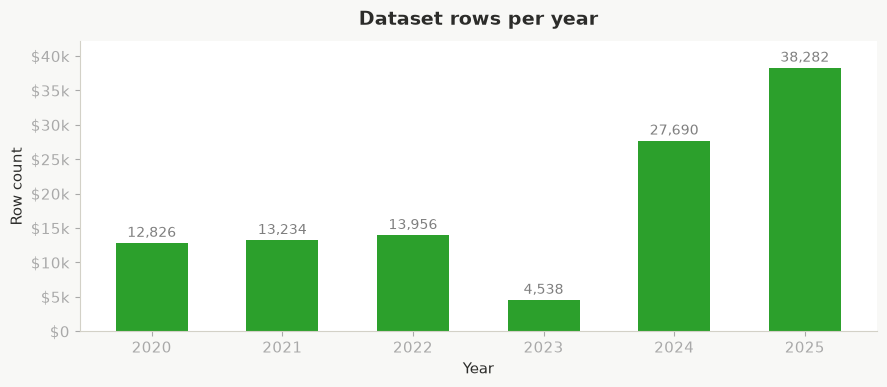

In [36]:
row_count_by_year(df, dataset_name="full", save_path=FIGURE_SAVE_PATH)

In [37]:
df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size,company_location,general_role
i64,str,i64,str,i64,str,str,str,str
2025,"""QA Engineer""",38000,"""Mid""",840,"""Onsite""","""Medium""","""United States""","""QA Engineer"""
2024,"""Machine Learning Engineer""",117200,"""Mid""",840,"""Onsite""","""Medium""","""United States""","""Machine Learning Engineer"""
2025,"""Analytics Engineer""",220000,"""Senior""",840,"""Onsite""","""Medium""","""United States""","""Data Engineer"""
2024,"""Software Engineer""",148000,"""Mid""",840,"""Onsite""","""Medium""","""United States""","""Software Engineer"""
2024,"""Cloud Engineer""",46400,"""Mid""",440,"""Onsite""","""Medium""","""Lithuania""","""Cloud Engineer"""
…,…,…,…,…,…,…,…,…
2022,"""Data Analyst""",29333,"""Entry""",76,"""Onsite""","""Enterprise""","""Brazil""","""Data Analyst"""
2021,"""Research Scientist""",159307,"""Senior""",36,"""Onsite""","""Enterprise""","""Australia""","""Research Scientist"""
2022,"""Research Scientist""",30487,"""Entry""",76,"""Hybrid""","""Startup""","""Brazil""","""Research Scientist"""


## C. Data visualization

### C.1. Requirements and plotting utilities

The plotting functions in this section are designed to work with Polars DataFrame with specific schema.

To ensure these functions execute correctly, please use an input dataframe containing the following columns:

- `year`: The year of the data [`Int64`]
- `salary_usd`: The salary in US dollars [`Int64`]
- `experience_level`: The experience level [`String`] ('Entry', 'Mid', 'Senior', 'Lead', 'Executive')
- `company_size`: The size of the company [`String`] ('Small', 'Medium', 'Large', 'Enterprise')
- `work_mode`: The working arrangement [`String`] ('Remote', 'Hybrid', 'Onsite')
- `company_location`: The country where the company is located [`String`]
- `general_role`: The normalized job title [`String`] (e.g., 'Data Scientist', 'AI Engineer')

In [38]:
LEVEL_ORDER = ["Entry", "Mid", "Senior", "Lead", "Executive"]
SIZE_ORDER = ["Small", "Medium", "Large", "Enterprise", "Startup"]

In [39]:
# Builds a fixed mapping of roles -> colors.
# Roles are ranked by a weighted score of average salary + count
# So that roles with high average + high count get better colors
role_counts = (
    df.group_by("general_role")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)

all_job_roles = role_counts.get_column("general_role").to_list()

excluded_color_indices = { 7 }
colors = [
    c
    for i, c in enumerate(colorcet.glasbey_category10)
    if i not in excluded_color_indices
]

ROLE_COLOR_MAP = {
    role: colors[i % len(colors)]
    for i, role in enumerate(all_job_roles)
}

In [40]:
GRID_ALPHA_VAL = 0.4
def add_grid(ax):
    ax.grid(True, axis="y", alpha=GRID_ALPHA_VAL, linestyle="--")

In [41]:
def plot_salary_distribution(df, save_path=None):
  sal_vals = df["salary_usd"].to_numpy()

  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  fig.patch.set_facecolor(BG)

  # Distribution in normal scale
  ax = axes[0]
  ax.hist(sal_vals, bins=80, color=PALETTE[0], edgecolor=CARD, linewidth=0.4)
  ax.set_xlabel("Salary (USD)")
  ax.set_ylabel("Count")
  ax.xaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
  ax.set_xlim(left=0)
  ax.axvline(np.mean(sal_vals), color=PALETTE[1], lw=1.5,
              linestyle="--", label=f"Mean   {currency_formatter(np.mean(sal_vals))}")
  ax.axvline(np.median(sal_vals), color=PALETTE[3], lw=1.5,
              linestyle="--", label=f"Median {currency_formatter(np.median(sal_vals))}")
  ax.legend(fontsize=10)

  # Distribution in log scale
  ax = axes[1]
  log_sal = np.log1p(sal_vals)
  ax.hist(log_sal, bins=80, color=PALETTE[2], edgecolor=CARD, linewidth=0.4)
  ax.set_xlabel("log(Salary + 1)")
  ax.set_title("Log-salary distribution", fontsize=13, fontweight="bold")
  plt.suptitle("Salary distribution", fontsize=15, fontweight="bold")
  plt.tight_layout()

  if save_path:
      save(fig, f"{save_path}/1a_salary_distribution")
  else:
      plt.show()
  plt.close(fig)

In [42]:
def plot_violin_salary_by_year(df, save_path=None):
    years_sorted = sorted(df["year"].unique().to_list())
    sal_by_year = [
        df.filter(pl.col("year") == y)["salary_usd"].to_numpy()
        for y in years_sorted
    ]

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(BG)

    vp = ax.violinplot(
        sal_by_year,
        positions=range(1, len(years_sorted) + 1),
        showmedians=True,
        showextrema=True
    )

    single_color = PALETTE[0]
    for body in vp["bodies"]:
        body.set_facecolor(single_color)
        body.set_alpha(0.3)
        body.set_edgecolor(single_color)

    vp["cmedians"].set_color(single_color)
    vp["cmedians"].set_linewidth(2)
    for part in ["cbars", "cmins", "cmaxes"]:
        vp[part].set_color(MUTED)

    ax.set_xticks(range(1, len(years_sorted) + 1))
    ax.set_xticklabels(years_sorted)
    ax.set_xlabel("Year")
    ax.set_ylabel("Salary (USD)")
    ax.set_title("Salary distribution per year", fontsize=14, fontweight="bold", pad=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
    ax.grid(axis="y")

    plt.tight_layout()
    if save_path:
        save(fig, f"{save_path}/1b_salary_violin_distribution_by_year")
    else:
        plt.show()
    plt.close(fig)

In [43]:
# Plots the mean and median salary trend over the years.

def plot_salary_trend(df, save_path=None):
    trend = (df.group_by("year")
               .agg([pl.mean("salary_usd").alias("mean"),
                     pl.median("salary_usd").alias("median")])
               .sort("year"))
    trend_pd = trend.to_pandas()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(BG)
    ax.fill_between(trend_pd["year"], trend_pd["mean"], trend_pd["median"],
                     alpha=0.12, color=PALETTE[1], label="_nolegend_")
    ax.plot(trend_pd["year"], trend_pd["mean"],
            "o-", lw=2.5, color=PALETTE[1], label="Mean salary", markersize=7)
    ax.plot(trend_pd["year"], trend_pd["median"],
            "s-", lw=2.5, color=PALETTE[3], label="Median salary", markersize=7)
    for _, row in trend_pd.iloc[[0, -1]].iterrows():
        ax.annotate(
            currency_formatter(row['mean']),
            (row["year"], row["mean"]),
            textcoords="offset points",
            xytext=(0, 9),
            ha="center",
            fontsize=9,
            color=PALETTE[1],
        )

    ax.margins(y=0.1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Salary (USD)")
    ax.set_title("Salary trend 2020–2025 — mean & median", fontsize=15, fontweight="bold", pad=14)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
    ax.legend(fontsize=11)
    ax.grid(axis="y")
    plt.tight_layout()

    if save_path:
        save(fig, f"{save_path}/1c_salary_mean_median")
    else:
        plt.show()
    plt.close(fig)

In [44]:
# Plots the share of each category within a feature over the years.

def plot_categorical_feature_share(df, feature, save_path=None):
    years_sorted = sorted(df["year"].unique().to_list())
    cats = sorted(df[feature].cast(str).unique().to_list())
    pivot = (df.with_columns(pl.col(feature).cast(str))
               .group_by(["year", feature])
               .agg(pl.len().alias("n"))
               .sort(["year", feature]))

    total_per_year = pivot.group_by("year").agg(pl.sum("n").alias("total"))
    pivot = (pivot.join(total_per_year, on="year")
                  .with_columns((pl.col("n") / pl.col("total") * 100).alias("pct")))

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(BG)
    bottom = np.zeros(len(years_sorted))

    for i, cat in enumerate(cats):
        vals = []
        for y in years_sorted:
            row = pivot.filter((pl.col("year") == y) & (pl.col(feature) == cat))
            vals.append(row["pct"][0] if len(row) else 0.0)
        ax.bar(years_sorted, vals, bottom=bottom,
               label=str(cat), color=PALETTE[i % len(PALETTE)], width=0.6)
        bottom += np.array(vals)

    ax.set_xlabel("Year")
    ax.set_ylabel("Share (%)")
    ax.set_title(f"{feature} — share per year", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylim(0, 105)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.7)
    ax.grid(axis="y")
    plt.tight_layout()
    if save_path:
        save(fig, f"{save_path}/1d_feature_share_by_year")
    else:
        plt.show()
    plt.close(fig)

In [45]:
def plot_entry_level_salary_trends(df, min_years=4, save_path=None, highlighted_roles=None):
    """
    Plots average entry-level salary trends by role over time.

    Args:
        df (pl.DataFrame): Input DataFrame.
        min_years (int): Minimum years a role must appear to be included.
        save_path (str, optional): Path to save the figure.
        highlighted_roles (list, optional): Roles to highlight. If None, all roles are colored; otherwise, other roles are shown in grey.
    """
    EXP_COL = "experience_level"
    SALARY_COL = "salary_usd"
    ROLE_COL = "general_role"
    YEAR_COL = "year"

    df_entry = (
        df
        .filter(pl.col(EXP_COL) == "Entry")
        .group_by([YEAR_COL, ROLE_COL])
        .agg(pl.col(SALARY_COL).mean().alias("avg_salary"))
        .sort([ROLE_COL, YEAR_COL])
    )

    valid_titles = (
        df_entry.group_by(ROLE_COL)
        .agg(pl.col(YEAR_COL).n_unique().alias("n_years"))
        .filter(pl.col("n_years") >= min_years)
        .get_column(ROLE_COL)
        .to_list()
    )

    df_plot = df_entry.filter(pl.col(ROLE_COL).is_in(valid_titles))

    order_2025 = (
        df_plot.filter(pl.col(YEAR_COL) == 2025)
        .sort("avg_salary", descending=True)
        .get_column(ROLE_COL)
        .to_list()
    )

    available_roles = df_plot.get_column(ROLE_COL).unique().to_list()
    remaining_roles = [r for r in available_roles if r not in order_2025]
    legend_order = order_2025 + remaining_roles

    fig, ax = plt.subplots(figsize=(12, 7))

    other_roles_added = False

    for title in legend_order:
        highlighted = highlighted_roles is None or title in highlighted_roles

        if highlighted:
            color = ROLE_COLOR_MAP.get(title, MUTED)
            alpha = 1
            zorder = 2
            label = title
        else:
            color = MUTED
            alpha = 0.5
            zorder = 1.5
            if not other_roles_added:
                label = "Other roles"
                other_roles_added = True
            else:
                label = "_nolegend_"

        sub = (
            df_plot
            .filter(pl.col(ROLE_COL) == title)
            .sort(YEAR_COL)
        )

        years = sub.get_column(YEAR_COL).to_list()
        salaries = sub.get_column("avg_salary").to_list()

        ax.plot(
            years,
            salaries,
            marker="o",
            linewidth=3 if highlighted and highlighted_roles is not None else 2,
            markersize=5,
            color=color,
            alpha=alpha,
            zorder=zorder,
            label=label,
        )

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Average salary (USD)", fontsize=12)
    ax.set_title(
        "Entry level salary for jobs in Data Science",
        fontsize=14,
        fontweight="bold",
    )

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # max_salary = df_plot.get_column("avg_salary").max()
    # ax.set_ylim(0, max_salary * 1.05)
    add_grid(ax)

    handles, labels = ax.get_legend_handles_labels()
    if "Other roles" in labels:
        i = labels.index("Other roles")
        handles.append(handles.pop(i))
        labels.append(labels.pop(i))

    ax.legend(
        handles,
        labels,
        title="Job role",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        title_fontsize=10,
    )

    plt.tight_layout()

    if save_path:
        save(fig, f"{save_path}/2a_average_entry_level")
    else:
        plt.show()

    plt.close(fig)

In [46]:
from collections import namedtuple

Point = namedtuple("Point", ["x", "y", "text", "color"])

def add_balanced_annotations(ax, points, x_offset=20, y_close_threshold=5000):
    """
    Annotate points, fanning out labels only when they're close in y (so they'd overlap)
    points: list of Point(x, y, text, color)
    y_close_threshold: points within this y distance of each other are treated as overlapping.
    """
    if not points:
        return

    x_values = sorted(set(p.x for p in points))
    x_avg = sum(x_values) / len(x_values)

    # only points sharing the same x can visually overlap vertically, so group by x first
    for x_val in x_values:
        same_x = [p for p in points if p.x == x_val]

        # Skip if no points
        if not same_x:
            continue

        # Annotate only min and max points
        min_p = min(same_x, key=lambda p: p.y)
        max_p = max(same_x, key=lambda p: p.y)
        to_plot = [min_p, max_p]

        for p in to_plot:
            y_off = 3
            x_off = -x_offset if p.x < x_avg else x_offset

            ax.annotate(
                p.text, (p.x, p.y),
                textcoords="offset points",
                xytext=(x_off, y_off),
                fontsize=8.5,
                fontweight="bold",
                color=p.color,
                ha="center",
            )

In [47]:
TARGET_EXPERIENCE_LEVELS = ["Entry", "Mid", "Senior", "Lead"]

In [48]:
def plot_salary_by_experience_level(df, target_roles, save_path=None, year_filter=None, ylim=None):
    """
    Plots salary by experience level for specified target roles, across all years.

    Args:
        df (pl.DataFrame): The input DataFrame.
        target_roles (list): A list of job roles to include in the plot.
        save_path (str, optional): Path to save the figure. Defaults to None.
        year_filter (int, optional): Optional year to filter the data. If None, uses all years.
        ylim (tuple, optional): Y-axis limits as (min, max). If None, no hard limit.
    """
    df_filtered = df.filter(
        pl.col("general_role").str.to_lowercase().is_in([r.lower() for r in target_roles]) &
        pl.col("experience_level").is_in(TARGET_EXPERIENCE_LEVELS)
    )

    if year_filter is not None:
        df_filtered = df_filtered.filter(pl.col("year") == year_filter)

    levels_in_data = (
        df_filtered.filter(pl.col("general_role").is_in(target_roles))
        .get_column("experience_level")
        .unique()
        .to_list()
    )
    present_levels = [lvl for lvl in LEVEL_ORDER if lvl in levels_in_data]
    level_map = {lvl: i for i, lvl in enumerate(present_levels)}

    df_grouped = (
        df_filtered
        .filter(pl.col("general_role").is_in(target_roles))
        .group_by(["general_role", "experience_level"])
        .agg(pl.col("salary_usd").mean().alias("avg_salary"))
        .with_columns(
            pl.col("experience_level").replace(level_map, default=None).alias("level_x")
        )
        .filter(pl.col("level_x").is_not_null())
        .sort(["general_role", "level_x"])
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    annotation_points = []
    for role_idx, role in enumerate(target_roles):
        color = ROLE_COLOR_MAP.get(role, MUTED)
        sub = df_grouped.filter(pl.col("general_role") == role).sort("level_x")
        x_vals = sub.get_column("level_x").to_list()
        y_vals = sub.get_column("avg_salary").to_list()
        levels = sub.get_column("experience_level").to_list()

        ax.plot(x_vals, y_vals, marker="o", linewidth=2.5, markersize=7,
                color=color, label=role, zorder=2)

        if len(x_vals) > 0:
            for i in {0, len(x_vals) - 1}:
                x, y = x_vals[i], y_vals[i]
                annotation_points.append(Point(x, y, currency_formatter(y), color))

    add_balanced_annotations(ax, annotation_points)
    ax.margins(x=0.11)

    if ylim is not None:
        ymin, ymax = ylim
        ax.set_ylim(ymin, ymax)

    ax.set_xticks([level_map[lvl] for lvl in present_levels])
    ax.set_xticklabels(present_levels, fontsize=11)
    ax.set_xlabel("Experience Level", fontsize=12)
    ax.set_ylabel("Average salary (USD)", fontsize=12)
    ax.set_title("Salary by Experience Level", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
    add_grid(ax)
    ax.legend(title="Job role", bbox_to_anchor=(1.02, 1), loc="upper left",
              fontsize=9.5, title_fontsize=10.5)

    plt.tight_layout()
    if save_path:
        save(fig, f"{save_path}/2b_salary_level")
    else:
        plt.show()
    plt.close(fig)

In [49]:
def plot_role_salary_by_level_and_company_size(df, target_roles, save_path=None, year_filter=None, ylim=None, highlighted_role_sizes=None):
    """
    Plots average salary by experience level for each company size, grouped by role,

    Args:
        df (pl.DataFrame): Input DataFrame.
        target_roles (list): Job roles to plot.
        save_path (str, optional): Output file path.
        year_filter (int, optional): Filter data to a specific year. If None, uses all years.
        ylim (tuple, optional): Y-axis limits as (min, max). If None, no hard limit.
        highlighted_role_sizes (dict, optional): Role/company-size combinations to highlight. Others are shown in grey. If None, all are highlighted.
    """

    # Use different marker shapes + line style for different company size, keeping the color for roles to be consistent
    marker_map = {
        "Startup": "P",
        "Small": "o",
        "Medium": "^",
        "Large": "s",
        "Enterprise": "s",
    }
    linestyle_map = {
        "Startup": "--",
        "Small": "-",
        "Medium": "-",
        "Large": "-",
        "Enterprise": "--",
    }

    df_filtered = df.filter(pl.col("experience_level").is_in(TARGET_EXPERIENCE_LEVELS))

    for role in target_roles:
        color = ROLE_COLOR_MAP.get(role, MUTED)
        df_role = df_filtered.filter(pl.col("general_role") == role)

        if year_filter is not None:
            df_role = df_role.filter(pl.col("year") == year_filter)

        levels_in_role = df_role.get_column("experience_level").unique().to_list()
        role_present_levels = [lvl for lvl in LEVEL_ORDER if lvl in levels_in_role]
        role_level_map = {lvl: i for i, lvl in enumerate(role_present_levels)}

        df_role_grouped = (
            df_role
            .group_by(["company_size", "experience_level"])
            .agg(pl.col("salary_usd").mean().alias("avg_salary"))
            .with_columns(
                pl.col("experience_level").replace(role_level_map, default=None).alias("level_x")
            )
            .filter(pl.col("level_x").is_not_null())
            .sort(["company_size", "level_x"])
        )

        sizes_in_data = df_role_grouped.get_column("company_size").unique().to_list()
        present_sizes = [s for s in SIZE_ORDER if s in sizes_in_data]

        fig, ax = plt.subplots(figsize=(9, 6))

        annotation_points = []

        for i, size in enumerate(present_sizes):
            highlighted = highlighted_role_sizes is None or size in highlighted_role_sizes.get(role, [])

            if highlighted:
                size_color = color
                zorder = 2
            else:
                size_color = MUTED
                zorder = 1.5

            marker = marker_map.get(size, "o")
            linestyle = linestyle_map.get(size, "-")
            sub = df_role_grouped.filter(pl.col("company_size") == size).sort("level_x")
            x_vals = sub.get_column("level_x").to_list()
            y_vals = sub.get_column("avg_salary").to_list()

            ax.plot(
                x_vals, y_vals,
                marker=marker,
                linewidth=2,
                markersize=7,
                color=size_color,
                linestyle=linestyle,
                label=size,
                zorder=zorder
            )

            if len(x_vals) > 0:
                for i in {0, len(x_vals) - 1}:
                    x, y = x_vals[i], y_vals[i]
                    annotation_points.append(Point(x, y, currency_formatter(y), size_color))

        add_balanced_annotations(ax, annotation_points)
        ax.margins(x=0.105)

        if ylim is not None:
            ymin, ymax = ylim
            ax.set_ylim(ymin, ymax)

        ax.set_xticks(list(role_level_map.values()))
        ax.set_xticklabels(role_present_levels, fontsize=11)
        ax.set_xlabel("Experience Level", fontsize=12)
        ax.set_ylabel("Average salary (USD)", fontsize=12)
        ax.set_title(f"{role} — Salary by Level & Company Size",
                     fontsize=13, fontweight="bold")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
        add_grid(ax)
        ax.legend(
            title="Company size",
            fontsize=9.5, title_fontsize=10.5, loc="best",
            handlelength=3.5, handletextpad=1.0    # extend the lines
        )

        plt.tight_layout()
        if save_path:
            save(fig, f"{save_path}/2c_salary_level_company_size_{role.replace(' ', '_')}")
        else:
            plt.show()
        plt.close(fig)

In [50]:
def plot_salary_by_country_and_level(df, target_roles, top_n_countries=None, countries=None, save_path=None, year_filter=None, ylim=None):
    """
    Generates subplots comparing salary by country and experience level for specified target roles, across all years.

    Args:
        df (pl.DataFrame): The input DataFrame.
        target_roles (list): A list of job roles to plot.
        top_n_countries (int, optional): The number of top countries to show for each role (auto-selected per role
            by frequency). Mutually exclusive with `countries`.
        countries (list, optional): Explicit list of countries to plot for every role. Mutually exclusive with
            `top_n_countries`.
        save_path (str, optional): Path to save the figure. Defaults to None.
        year_filter (int, optional): Optional year to filter the data. If None, uses all years.
    """
    df_filtered = df.filter(pl.col("experience_level").is_in(TARGET_EXPERIENCE_LEVELS))

    if (top_n_countries is None) == (countries is None):
        raise ValueError("Provide exactly one of `top_n_countries` or `countries`.")

    if year_filter is not None:
        df_filtered = df_filtered.filter(pl.col("year") == year_filter)

    role_countries = {}
    selected_countries = set()

    if countries is not None:
        # Explicit mode: same fixed list of countries used for every role.
        for role in target_roles:
            role_countries[role] = countries
        selected_countries.update(countries)
    else:
        # Auto mode: pick the top_n most frequent countries per role.
        for role in target_roles:
            top_countries = (
                df_filtered.filter(pl.col("general_role") == role)
                .group_by("company_location")
                .agg(pl.len().alias("n"))
                .sort("n", descending=True)
                .head(top_n_countries)
                .get_column("company_location")
                .to_list()
            )
            role_countries[role] = top_countries
            selected_countries.update(top_countries)

    selected_countries = sorted(selected_countries)

    # Do the color mapping for different countries
    if len(selected_countries) <= 10:
        palette = plt.cm.tab10.colors
    elif len(selected_countries) <= 20:
        palette = plt.cm.tab20.colors
    else:
        # More countries than 20: cycle through palette.
        palette = plt.cm.tab20.colors

    country_color_map = {
        country: palette[i % len(palette)]
        for i, country in enumerate(selected_countries)
    }

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for idx, role in enumerate(target_roles):
        ax = axes[idx]
        df_role_top = df_filtered.filter(
            (pl.col("general_role") == role) &
            (pl.col("company_location").is_in(role_countries[role]))
        )

        levels_in_role = df_role_top.get_column("experience_level").unique().to_list()
        role_present_levels = [lvl for lvl in LEVEL_ORDER if lvl in levels_in_role]
        role_level_map = {lvl: i for i, lvl in enumerate(role_present_levels)}

        df_role_grouped = (
            df_role_top
            .group_by(["company_location", "experience_level"])
            .agg(pl.col("salary_usd").mean().alias("avg_salary"))
            .with_columns(
                pl.col("experience_level").replace(role_level_map, default=None).alias("level")
            )
            .filter(pl.col("level").is_not_null())
            .sort(["company_location", "level"])
        )

        role_present_countries = df_role_grouped.get_column("company_location").unique().sort().to_list()
        annotation_points = []
        for country in role_present_countries:
            color = country_color_map.get(country, MUTED)
            sub = df_role_grouped.filter(pl.col("company_location") == country).sort("level")
            x_vals = sub.get_column("level").to_list()
            y_vals = sub.get_column("avg_salary").to_list()

            ax.plot(x_vals, y_vals, marker="o", linewidth=2, markersize=6, color=color, label=country)

            if len(x_vals) > 0:
                for i in {0, len(x_vals) - 1}:
                    x, y = x_vals[i], y_vals[i]
                    annotation_points.append(Point(x, y, currency_formatter(y), color))

        add_balanced_annotations(ax, annotation_points)
        ax.margins(x=0.12)

        if ylim is not None:
            ymin, ymax = ylim
            ax.set_ylim(ymin, ymax)

        ax.set_xticks(list(role_level_map.values()))
        ax.set_xticklabels(role_present_levels, fontsize=9)
        ax.set_title(role, fontsize=12, fontweight="bold")
        ax.set_xlabel("Experience Level", fontsize=10)
        ax.set_ylabel("Salary (USD)", fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
        add_grid(ax)
        ax.legend(title="Country", fontsize=7.5, title_fontsize=8, loc="best")

    for j in range(len(target_roles), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Compare salary by Country & Experience Level", fontsize=16, fontweight="bold")
    plt.tight_layout()
    if save_path:
        save(fig, f"{save_path}/2d_salary_level_country")
    else:
        plt.show()
    plt.close(fig)

### C.2. Basic figures

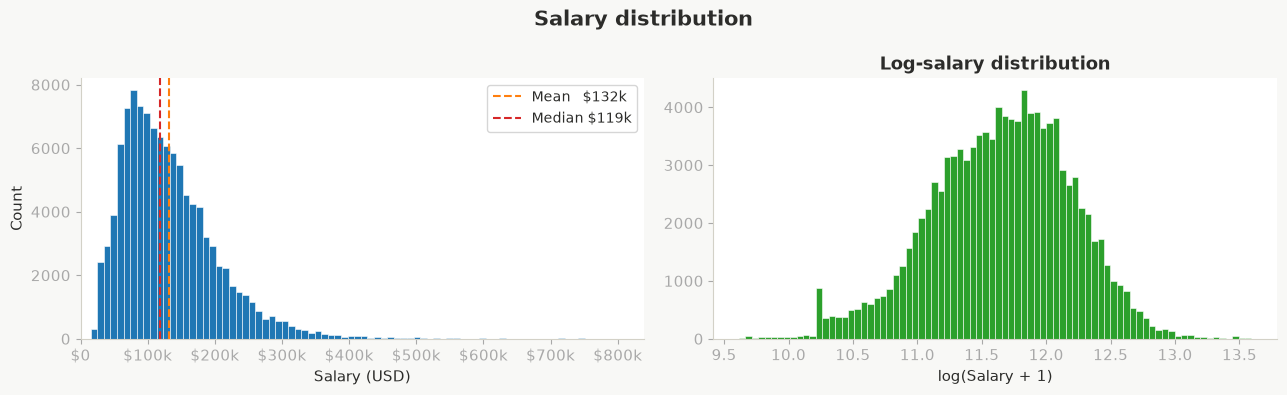

In [51]:
plot_salary_distribution(df, save_path=FIGURE_SAVE_PATH)

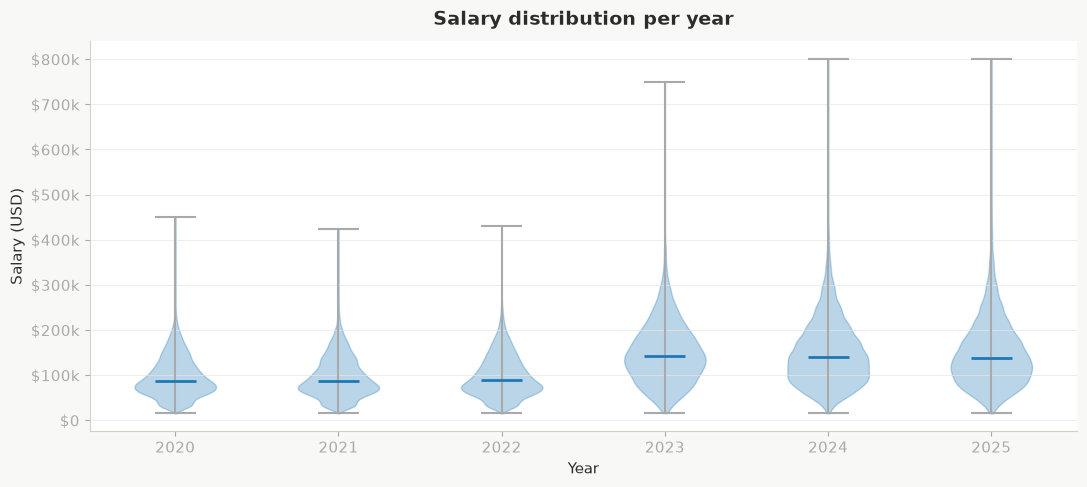

In [52]:
plot_violin_salary_by_year(df, save_path=FIGURE_SAVE_PATH)

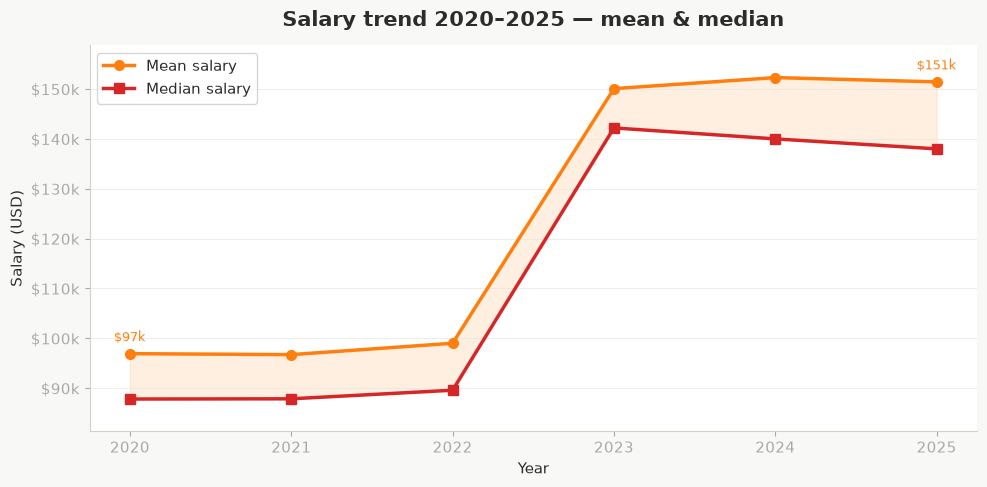

In [53]:
plot_salary_trend(df, save_path=FIGURE_SAVE_PATH)

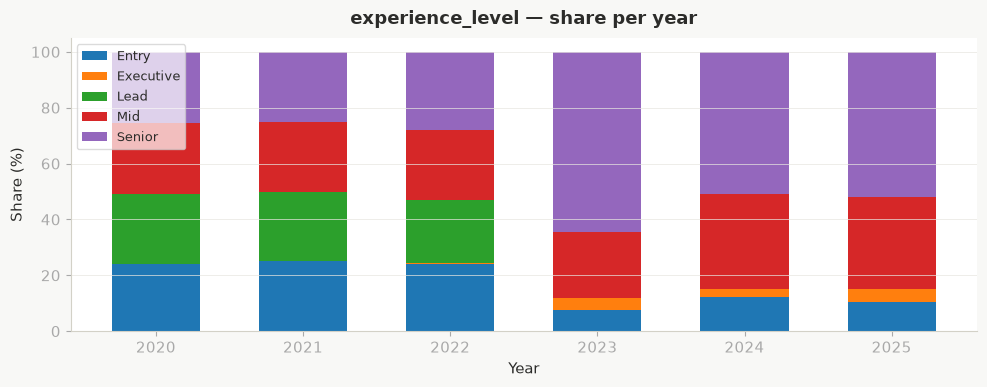

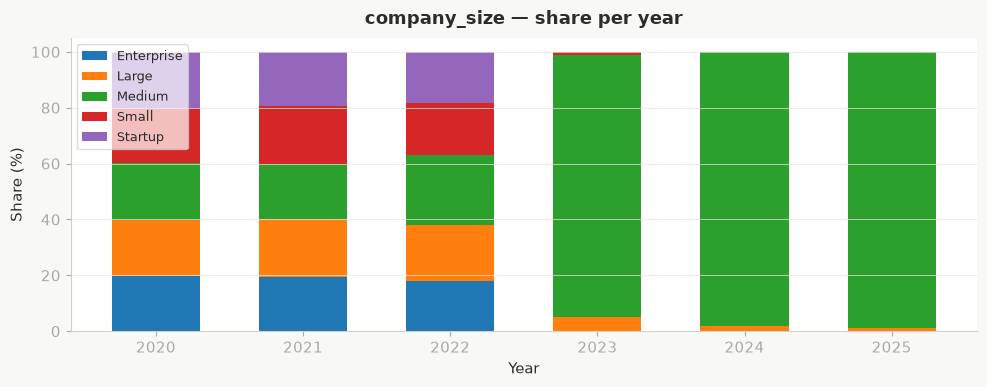

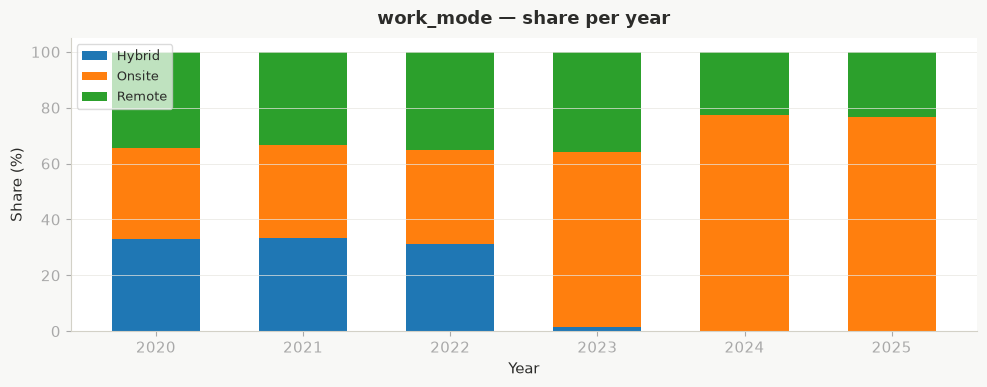

In [54]:
# Feature distributions
plot_categorical_feature_share(df, feature='experience_level', save_path=FIGURE_SAVE_PATH)
plot_categorical_feature_share(df, feature='company_size', save_path=FIGURE_SAVE_PATH)
plot_categorical_feature_share(df, feature='work_mode', save_path=FIGURE_SAVE_PATH)

### C.3. Further analysis

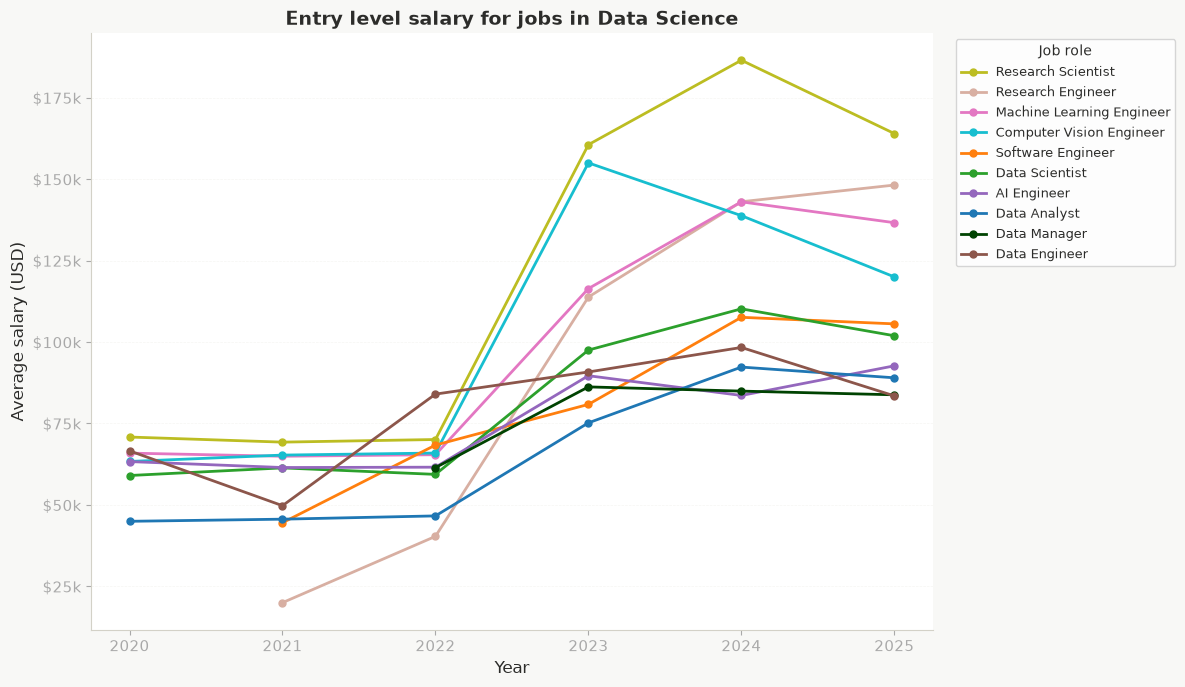

In [55]:
plot_entry_level_salary_trends(df, save_path=FIGURE_SAVE_PATH)

In [56]:
target_roles = [
    'Computer Vision Engineer',
    'Machine Learning Engineer',
    'Research Engineer',
    'Software Engineer',
    'Research Scientist'
]

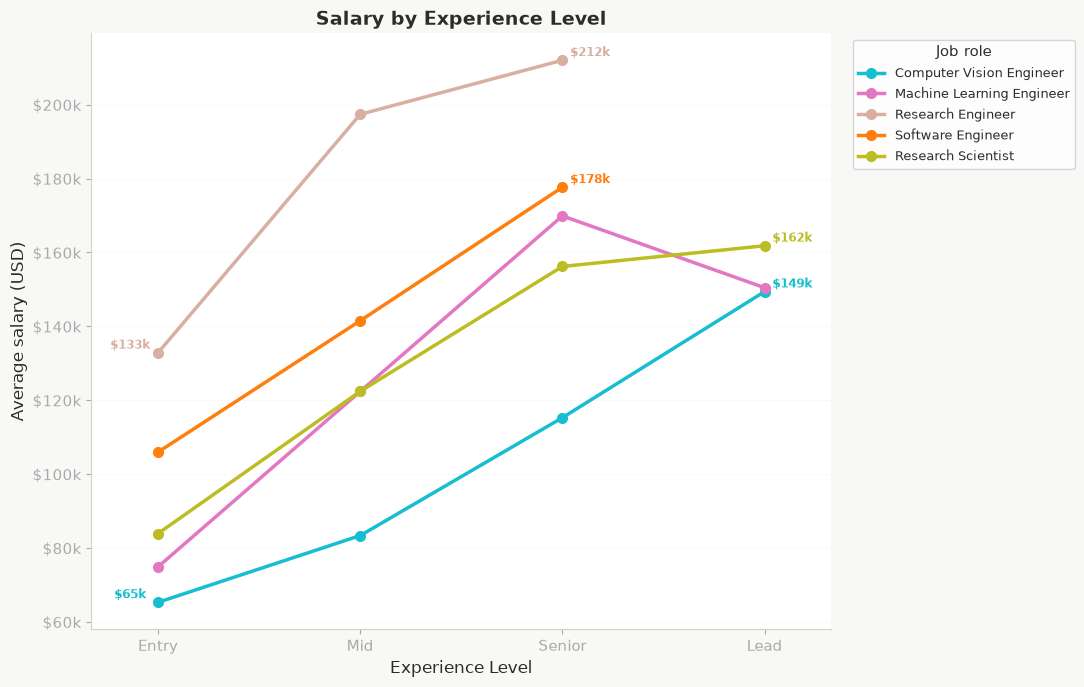

In [57]:
plot_salary_by_experience_level(
    df,
    target_roles=target_roles,
    save_path=FIGURE_SAVE_PATH
)

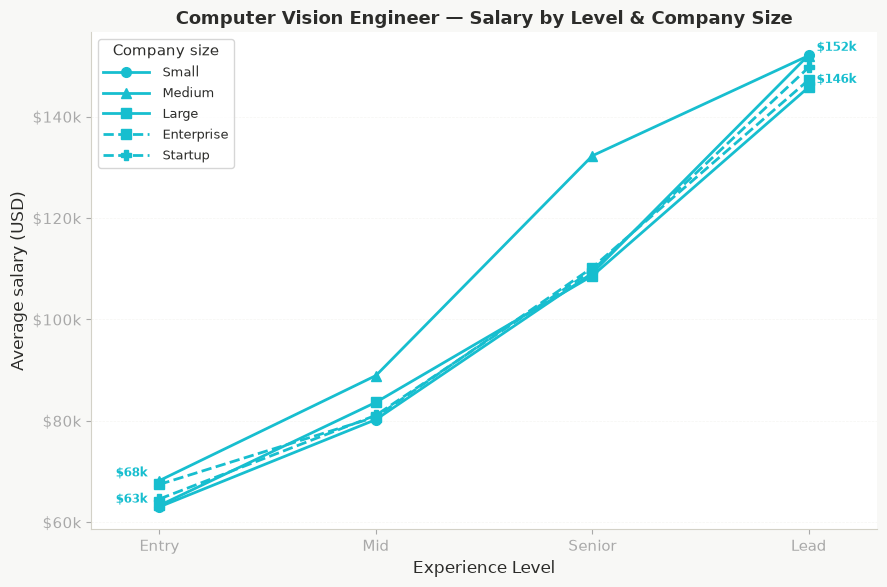

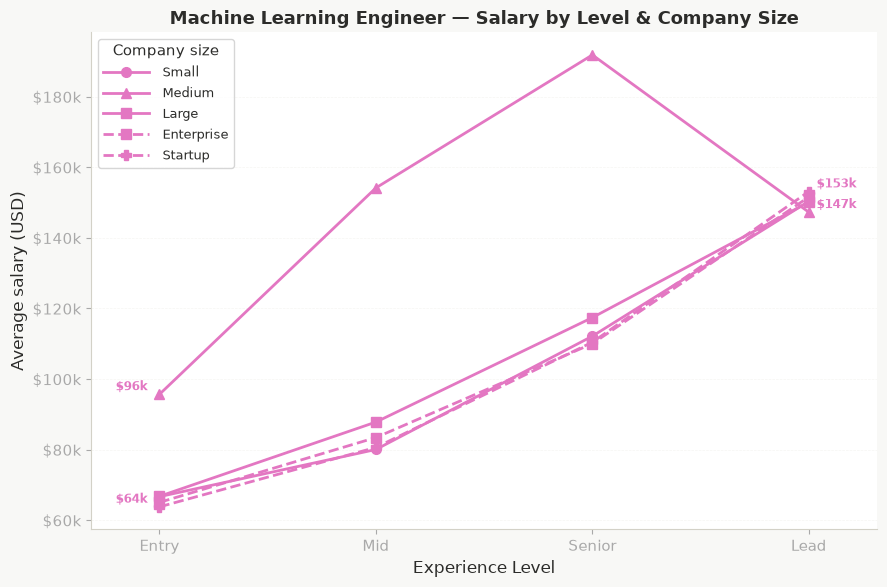

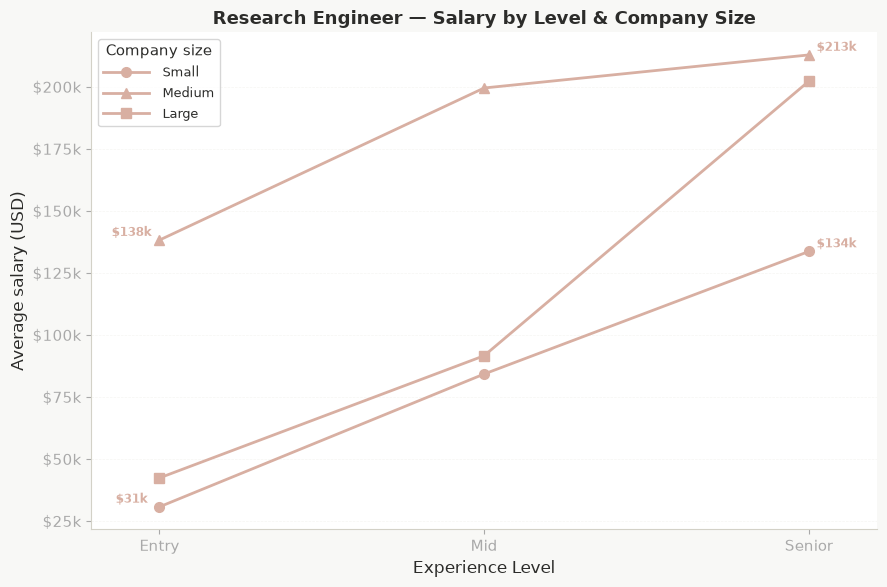

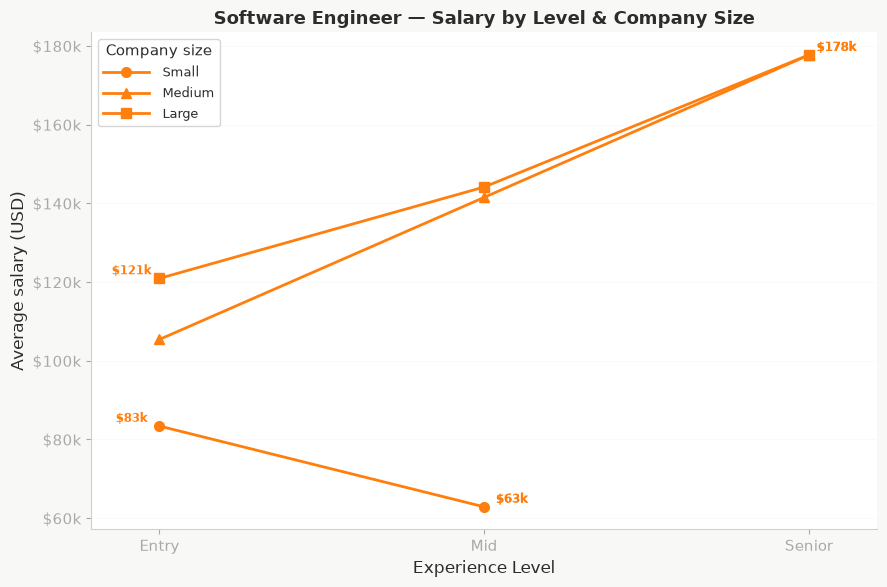

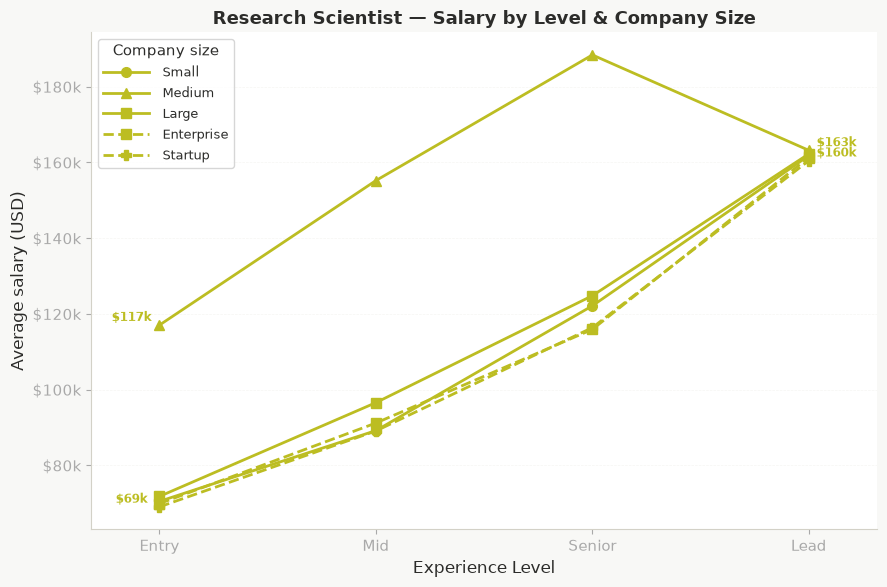

In [58]:
plot_role_salary_by_level_and_company_size(
    df,
    target_roles=target_roles,
    # year_filter=2025,
    save_path=FIGURE_SAVE_PATH
)

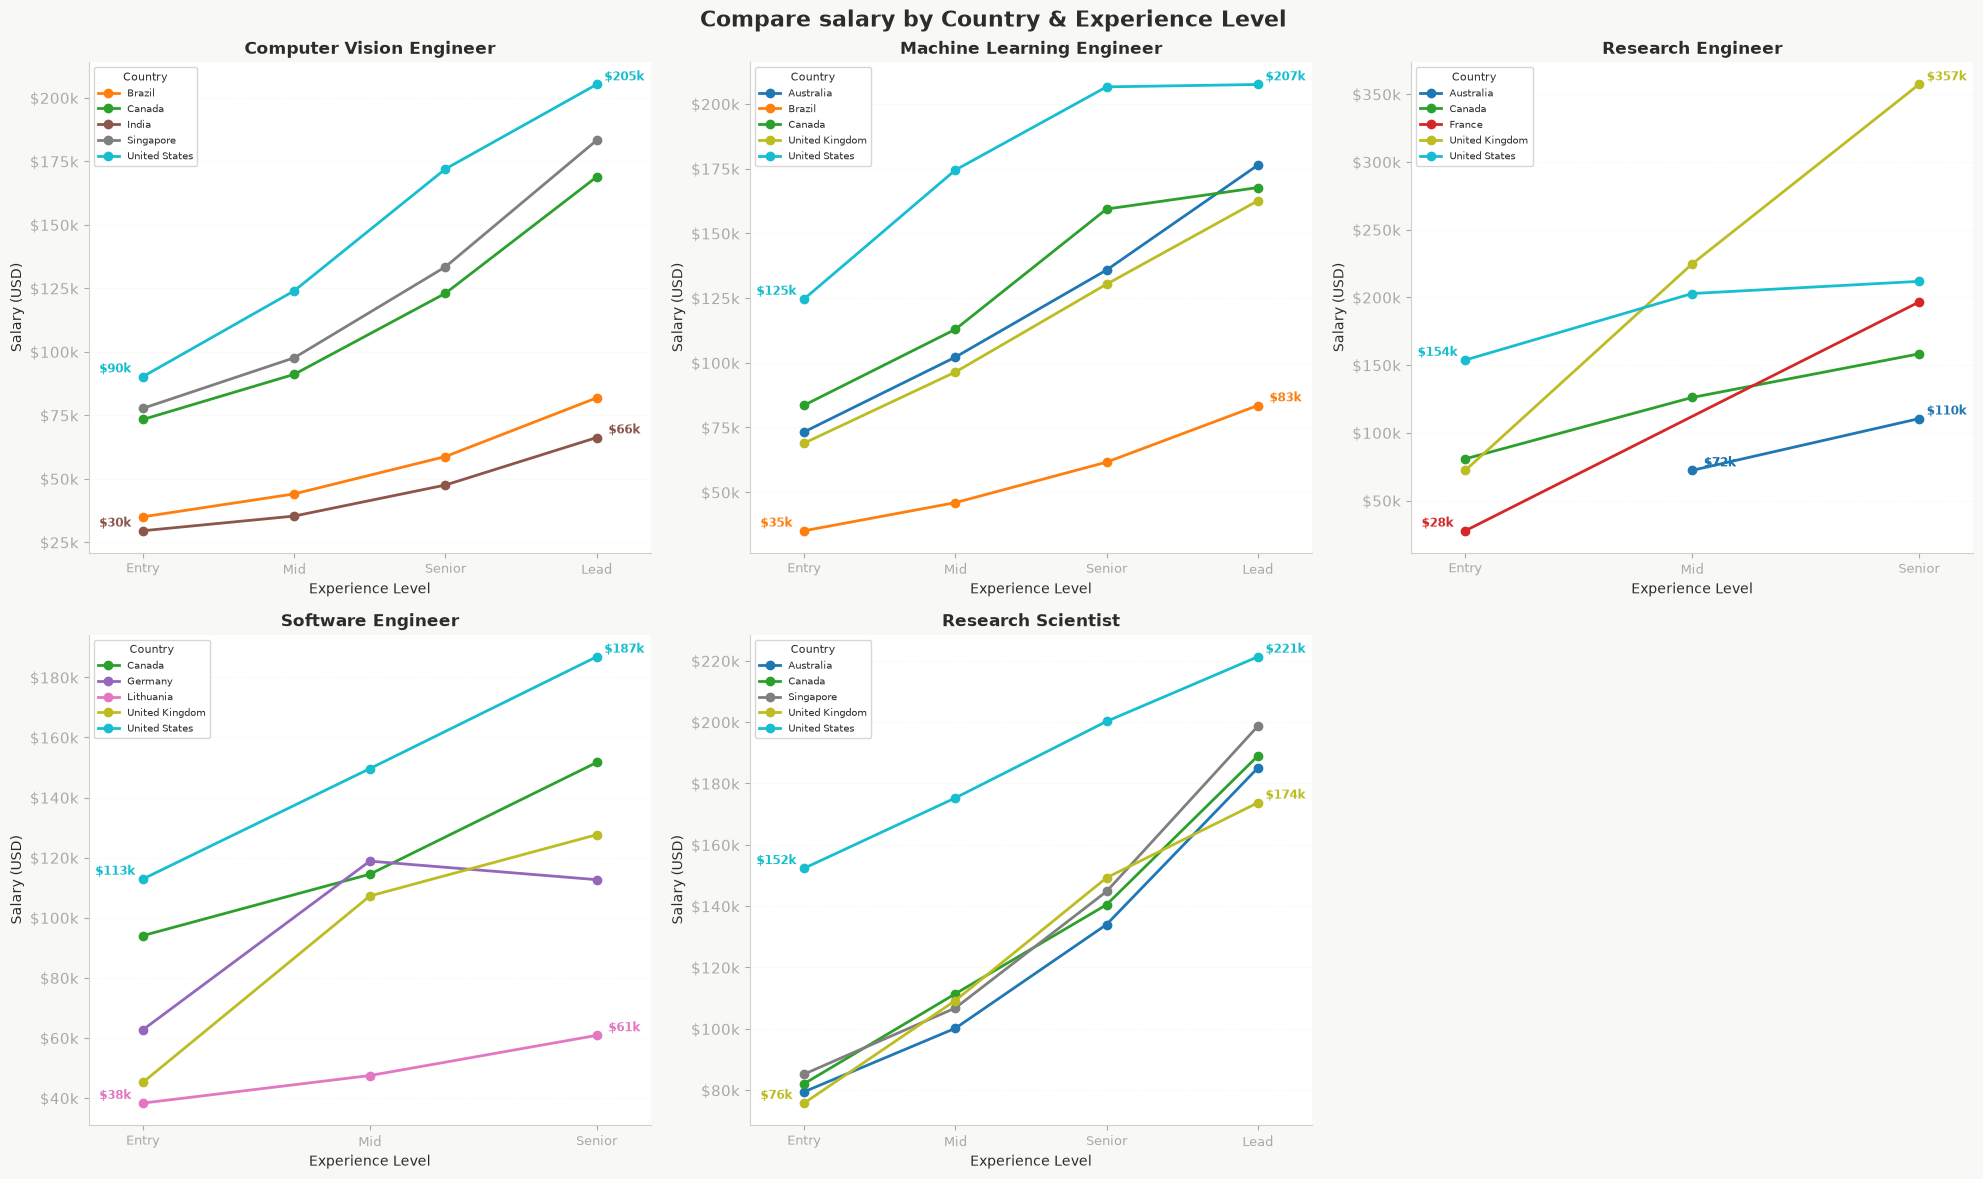

In [59]:
plot_salary_by_country_and_level(
    df,
    target_roles=target_roles,
    top_n_countries=5,
    # year_filter=2025,
    save_path=FIGURE_SAVE_PATH
)

### C.4. Relationship of features with salary

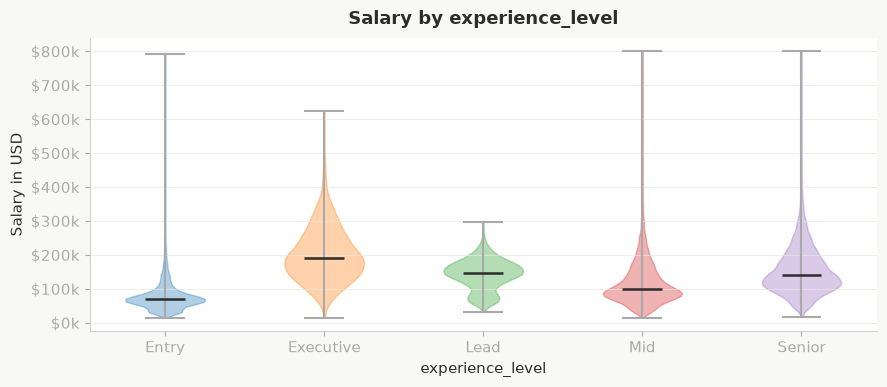

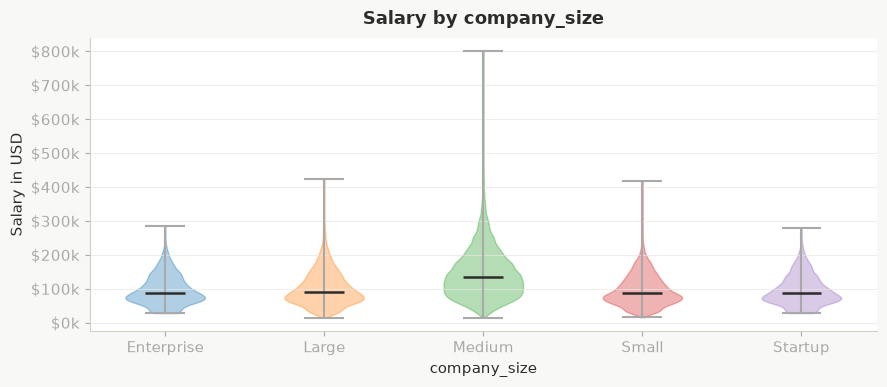

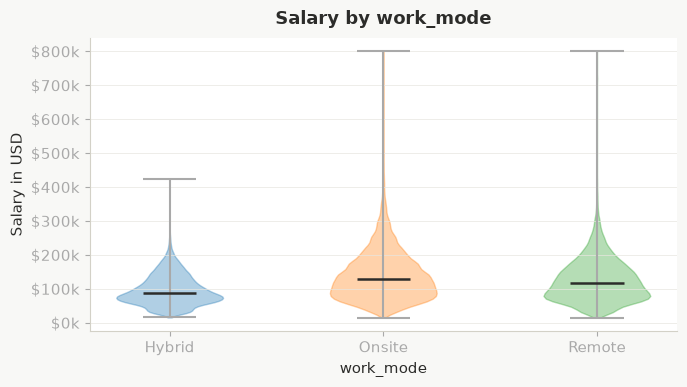

In [60]:
# ── Fig 4-1: Categorical features vs salary (violin plots) ───────

for feat in ["experience_level", "company_size", "work_mode"]:

    cats = sorted(df[feat].cast(str).unique().to_list())

    data = [
        df.filter(pl.col(feat).cast(str) == c)["salary_usd"]
        .to_numpy()
        for c in cats
    ]

    fig, ax = plt.subplots(figsize=(max(7, len(cats)*1.8), 4))
    fig.patch.set_facecolor(BG)

    vp = ax.violinplot(
        data,
        positions=range(1, len(cats) + 1),
        showmedians=True,
        showextrema=True
    )

    # violin body styling
    for body, c in zip(vp["bodies"], PALETTE):
        body.set_facecolor(c)
        body.set_edgecolor(c)
        body.set_alpha(0.35)

    # median styling
    vp["cmedians"].set_color(TEXT)
    vp["cmedians"].set_linewidth(1.8)

    # extrema styling
    for part in ["cbars", "cmins", "cmaxes"]:
        vp[part].set_color(MUTED)

    ax.set_xticks(range(1, len(cats) + 1))
    ax.set_xticklabels(cats)

    ax.set_xlabel(feat)
    ax.set_ylabel("Salary in USD")

    ax.set_title(
        f"Salary by {feat}",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"${x/1000:.0f}k"
        )
    )

    ax.grid(axis="y")

    plt.tight_layout()

    save(fig, f"{FIGURE_SAVE_PATH}/4a_salary_vs_{feat}")

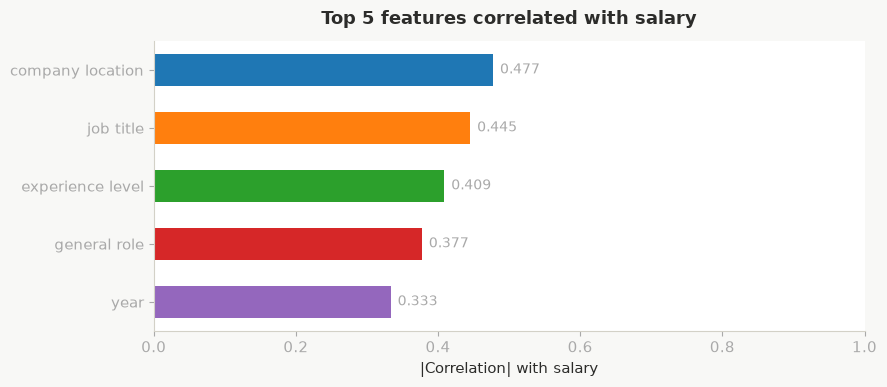

In [61]:
# ── Fig 4-2: Top 5 correlated features vs salary (bar chart) ─
# encode categoricals as group means for a proxy correlation

proxy = df.to_pandas().copy()
for c in ["experience_level", "company_size", "work_mode", "company_location", "job_title", "general_role"]:
    mapping = proxy.groupby(c)["salary_usd"].mean()
    proxy[c + "_enc"] = proxy[c].map(mapping)

enc_cols = [c for c in proxy.columns
            if c.endswith("_enc") or c in
            ["year","salary_usd"]]
corr_sal = (proxy[enc_cols]
            .corr()["salary_usd"]
            .drop("salary_usd")
            .abs()
            .sort_values(ascending=False)
            .head(5))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG)
labels = [l.replace("_enc","").replace("_"," ") for l in corr_sal.index]
ax.barh(labels[::-1], corr_sal.values[::-1],
        color=PALETTE[:5][::-1], height=0.55)
ax.set_xlabel("|Correlation| with salary")
ax.set_title("Top 5 features correlated with salary",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, 1)
for i, v in enumerate(corr_sal.values[::-1]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10, color=MUTED)
plt.tight_layout()
save(fig, f"{FIGURE_SAVE_PATH}/4b_top5_correlated_features")

## D. Adding data generated by our models

### D.1. Fetching the data

Because there are missing data for certain roles, the visualizations for section B are jagged and does not reflect a trend.

To compensate for that, we used our own model to generate a synthetic dataset covering various parameters:

*   **Years:** 2020, 2021, 2022, 2023
*   **Target Roles:** Computer Vision Engineer, Machine Learning Engineer, Research Engineer, Software Engineer, Research Scientist
*   **Experience Levels:** Entry, Mid, Senior, Lead
*   **Company Sizes:** Small, Medium, Large, Enterprise
*   **Target Countries:** United States, Australia, Netherlands, United Kingdom, Canada, Italy, Singapore, Germany, Finland

To ensure the following visualizations are reproducible, we have uploaded the data generated by our model to Google Drive.
You can download it via [this link](https://drive.google.com/file/d/1ru-f0H95DQH13BFq84Nz6Eo1mQ8wgQgs/view?usp=sharing).

Before running the next section, please do one of the following options:

1. Run `src/data_generation/generate_synthetic_viz_data.py` to generate the synthetic data using our model
2. Download the data file from Google Drive and place it in the `data/` folder

In [62]:
model_gen_data_path = "data/model_generated_data.csv"

In [63]:
if "google.colab" in str(get_ipython()):
    import gdown
    
    file_id = "1ru-f0H95DQH13BFq84Nz6Eo1mQ8wgQgs"
    Path("data").mkdir(parents=True, exist_ok=True)
    
    gdown.download(id=file_id, output=model_gen_data_path, quiet=False)

In [64]:
model_gen_df = pl.read_csv(model_gen_data_path)
model_gen_df

year,general_role,experience_level,company_size,company_location,predicted_salary_usd
i64,str,str,str,str,f64
2020,"""Computer Vision Engineer""","""Entry""","""Small""","""United States""",90823.57
2020,"""Computer Vision Engineer""","""Entry""","""Small""","""Australia""",74819.29
2020,"""Computer Vision Engineer""","""Entry""","""Small""","""Netherlands""",67609.04
2020,"""Computer Vision Engineer""","""Entry""","""Small""","""United Kingdom""",69545.42
2020,"""Computer Vision Engineer""","""Entry""","""Small""","""Canada""",73083.336
…,…,…,…,…,…
2025,"""Data Visualization""","""Lead""","""Enterprise""","""Canada""",125244.38
2025,"""Data Visualization""","""Lead""","""Enterprise""","""Italy""",102136.28
2025,"""Data Visualization""","""Lead""","""Enterprise""","""Singapore""",137744.88


### D.2. Match and merge data with available data

In [65]:
countries = (
    model_gen_df
    .select("company_location")
    .unique()
    .to_series()
    .to_list()
)

# build dictionary once
country_name_map = {
    c: country_numeric_from_name(c)
    for c in countries
}

In [66]:
model_gen_mapped_df = (model_gen_df
    .rename({ "predicted_salary_usd" : "salary_usd"})
    .with_columns([
        pl.col("general_role").alias("job_title"),
        pl.col("company_location").replace_strict(country_name_map).alias("company_location_code"),
        pl.lit("Onsite").alias("work_mode"),
        pl.col("salary_usd").round(0).cast(pl.Int64)
    ])
    .select(
        'year',
        'job_title',
        'salary_usd',
        'experience_level',
        'company_location_code',
        'work_mode',
        'company_size',
        'company_location',
        'general_role',
    )
)

model_gen_mapped_df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size,company_location,general_role
i64,str,i64,str,i64,str,str,str,str
2020,"""Computer Vision Engineer""",90824,"""Entry""",840,"""Onsite""","""Small""","""United States""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",74819,"""Entry""",36,"""Onsite""","""Small""","""Australia""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",67609,"""Entry""",528,"""Onsite""","""Small""","""Netherlands""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",69545,"""Entry""",826,"""Onsite""","""Small""","""United Kingdom""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",73083,"""Entry""",124,"""Onsite""","""Small""","""Canada""","""Computer Vision Engineer"""
…,…,…,…,…,…,…,…,…
2025,"""Data Visualization""",125244,"""Lead""",124,"""Onsite""","""Enterprise""","""Canada""","""Data Visualization"""
2025,"""Data Visualization""",102136,"""Lead""",380,"""Onsite""","""Enterprise""","""Italy""","""Data Visualization"""
2025,"""Data Visualization""",137745,"""Lead""",702,"""Onsite""","""Enterprise""","""Singapore""","""Data Visualization"""


In [67]:
# Filter out entries which already existed
keys = [
    "year",
    "general_role",
    "company_size",
    "company_location",
    "experience_level",
]

model_gen_filtered_df = model_gen_mapped_df.join(df.select(keys).unique(), on=keys, how="anti")
model_gen_filtered_df

year,job_title,salary_usd,experience_level,company_location_code,work_mode,company_size,company_location,general_role
i64,str,i64,str,i64,str,str,str,str
2020,"""Computer Vision Engineer""",55874,"""Entry""",380,"""Onsite""","""Small""","""Italy""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",46225,"""Entry""",246,"""Onsite""","""Small""","""Finland""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",55982,"""Entry""",380,"""Onsite""","""Medium""","""Italy""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",46333,"""Entry""",246,"""Onsite""","""Medium""","""Finland""","""Computer Vision Engineer"""
2020,"""Computer Vision Engineer""",56781,"""Entry""",380,"""Onsite""","""Large""","""Italy""","""Computer Vision Engineer"""
…,…,…,…,…,…,…,…,…
2025,"""Data Visualization""",125244,"""Lead""",124,"""Onsite""","""Enterprise""","""Canada""","""Data Visualization"""
2025,"""Data Visualization""",102136,"""Lead""",380,"""Onsite""","""Enterprise""","""Italy""","""Data Visualization"""
2025,"""Data Visualization""",137745,"""Lead""",702,"""Onsite""","""Enterprise""","""Singapore""","""Data Visualization"""


In [68]:
# Merging & validation
full_df = pl.concat(
    [
        model_gen_filtered_df,
        df
    ],
    how="vertical"
)

In [69]:
validate(full_df, "salary_usd")

1. Schema & unique counts per column:
  year                      dtype=Int64        nulls=0      unique=6
  job_title                 dtype=String       nulls=0      unique=425
  salary_usd                dtype=Int64        nulls=0      unique=49825
  experience_level          dtype=String       nulls=0      unique=5
  company_location_code     dtype=Int64        nulls=2      unique=97
  work_mode                 dtype=String       nulls=0      unique=3
  company_size              dtype=String       nulls=0      unique=5
  company_location          dtype=String       nulls=2      unique=97
  general_role              dtype=String       nulls=0      unique=36

2. Missing values summary:
shape: (9, 3)
┌───────────────────────┬───────┬──────────┐
│ column                ┆ nulls ┆ pct      │
│ ---                   ┆ ---   ┆ ---      │
│ str                   ┆ u32   ┆ f64      │
╞═══════════════════════╪═══════╪══════════╡
│ company_location_code ┆ 2     ┆ 0.001667 │
│ company_location  

### D.3. Visualize

In [70]:
ALT_FIGURE_SAVE_PATH = 'model_generated_graphs'
ALT_FIGURE_APPENDIX_SAVE_PATH = f"{ALT_FIGURE_SAVE_PATH}/appendix"
Path(ALT_FIGURE_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(ALT_FIGURE_APPENDIX_SAVE_PATH).mkdir(parents=True, exist_ok=True)

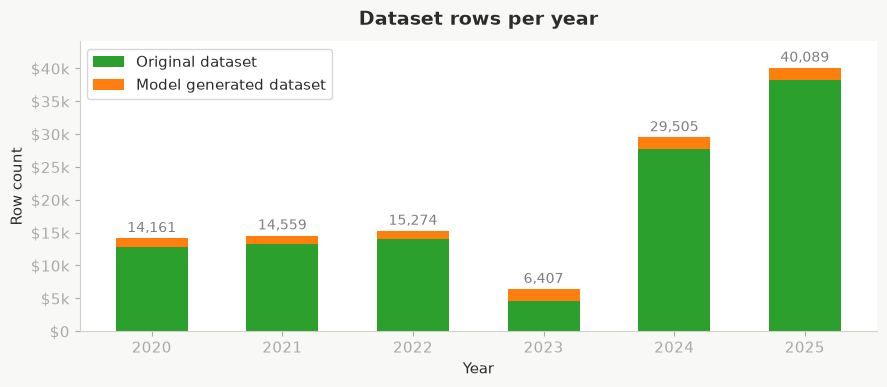

In [71]:
stacked_row_count_by_year(df, model_gen_filtered_df, labels=("Original dataset", "Model generated dataset"), save_path=ALT_FIGURE_SAVE_PATH)

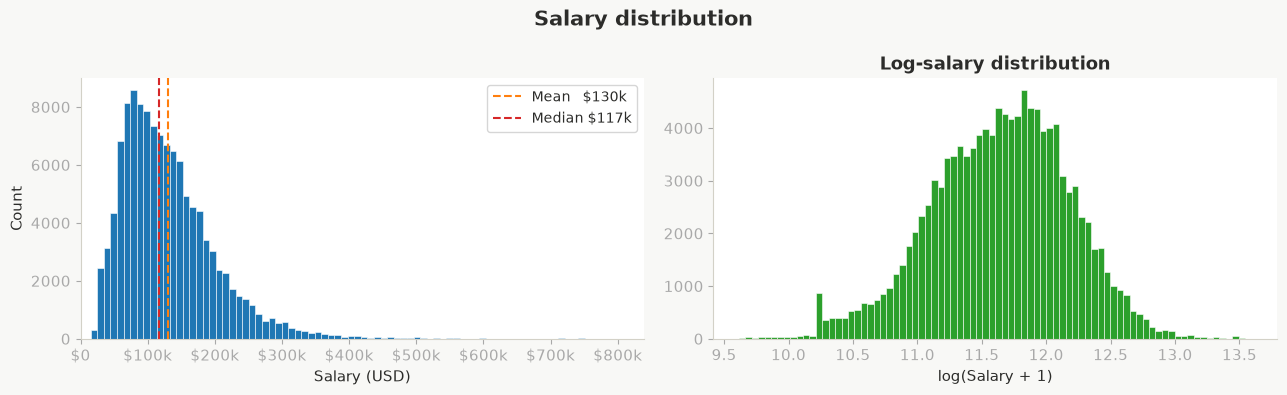

In [72]:
plot_salary_distribution(full_df, save_path=ALT_FIGURE_SAVE_PATH)

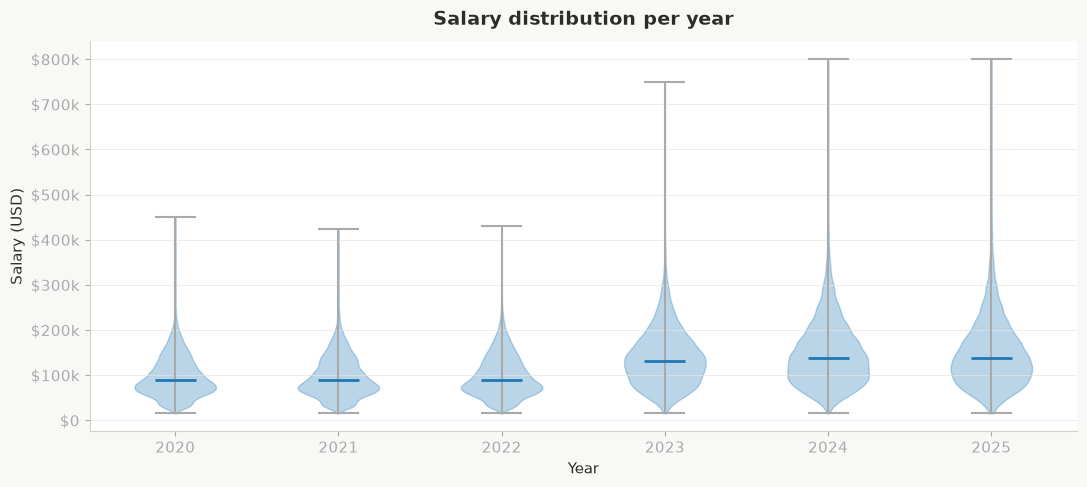

In [73]:
plot_violin_salary_by_year(full_df, save_path=ALT_FIGURE_SAVE_PATH)

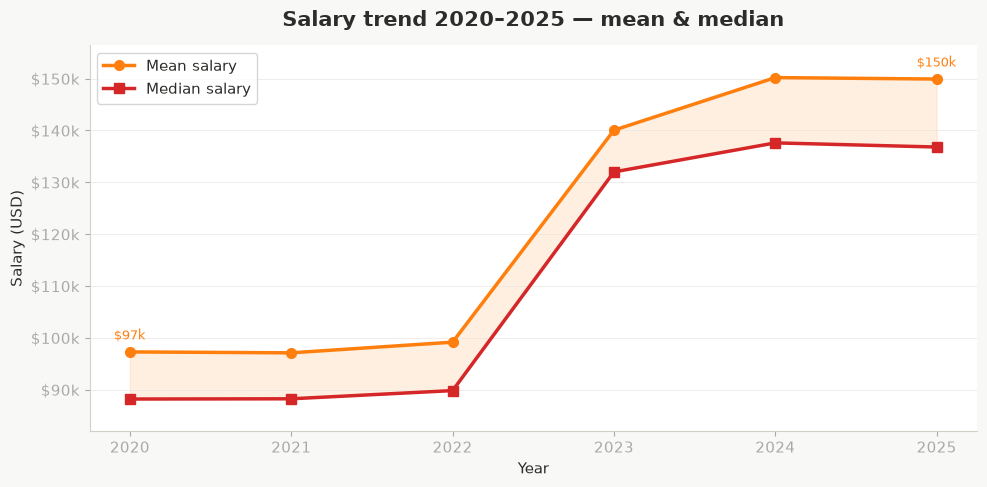

In [74]:
plot_salary_trend(full_df, save_path=ALT_FIGURE_SAVE_PATH)

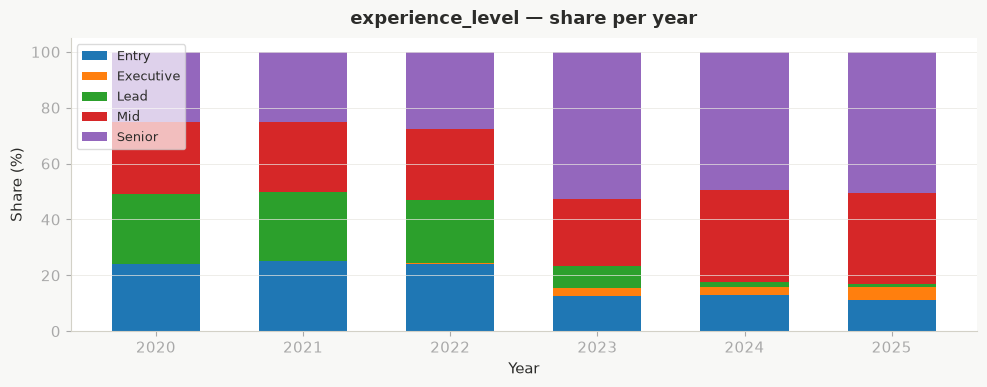

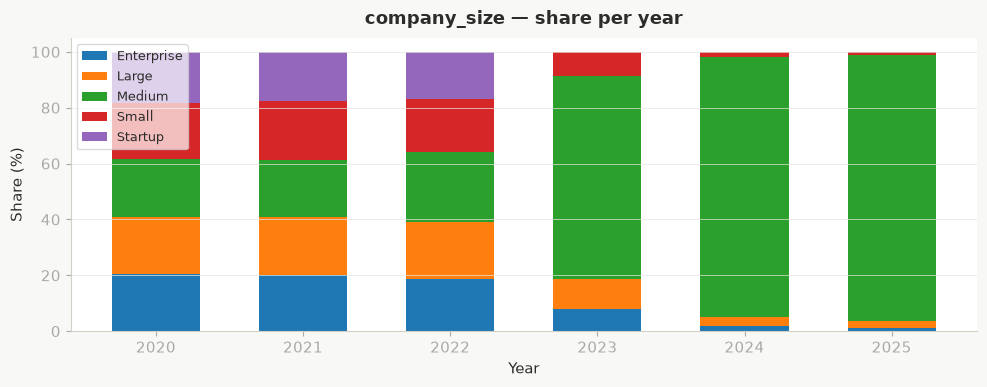

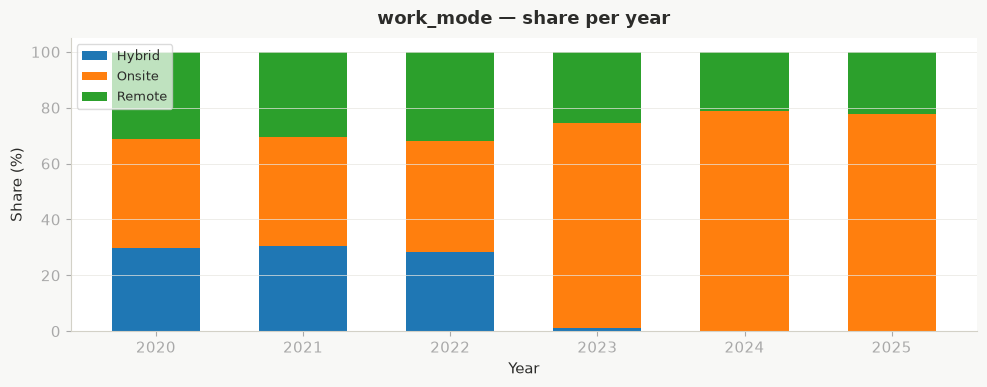

In [75]:
# Feature distributions
plot_categorical_feature_share(full_df, feature='experience_level', save_path=ALT_FIGURE_SAVE_PATH)
plot_categorical_feature_share(full_df, feature='company_size', save_path=ALT_FIGURE_SAVE_PATH)
plot_categorical_feature_share(full_df, feature='work_mode', save_path=ALT_FIGURE_SAVE_PATH)

### D.4. Further analysis

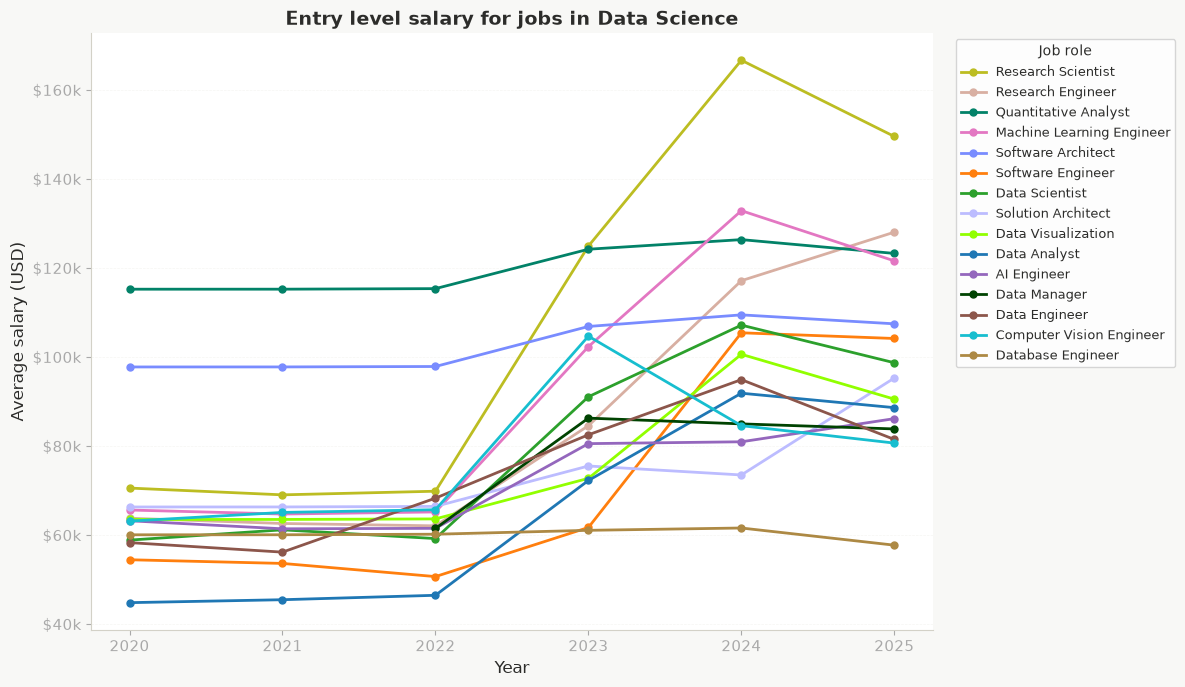

In [76]:
plot_entry_level_salary_trends(full_df, save_path=ALT_FIGURE_APPENDIX_SAVE_PATH)

In [77]:
target_roles = [
    'Machine Learning Engineer',
    'Research Engineer',
    'Research Scientist',
    'Quantitative Analyst',
    "Data Scientist",
    'Software Engineer',
]

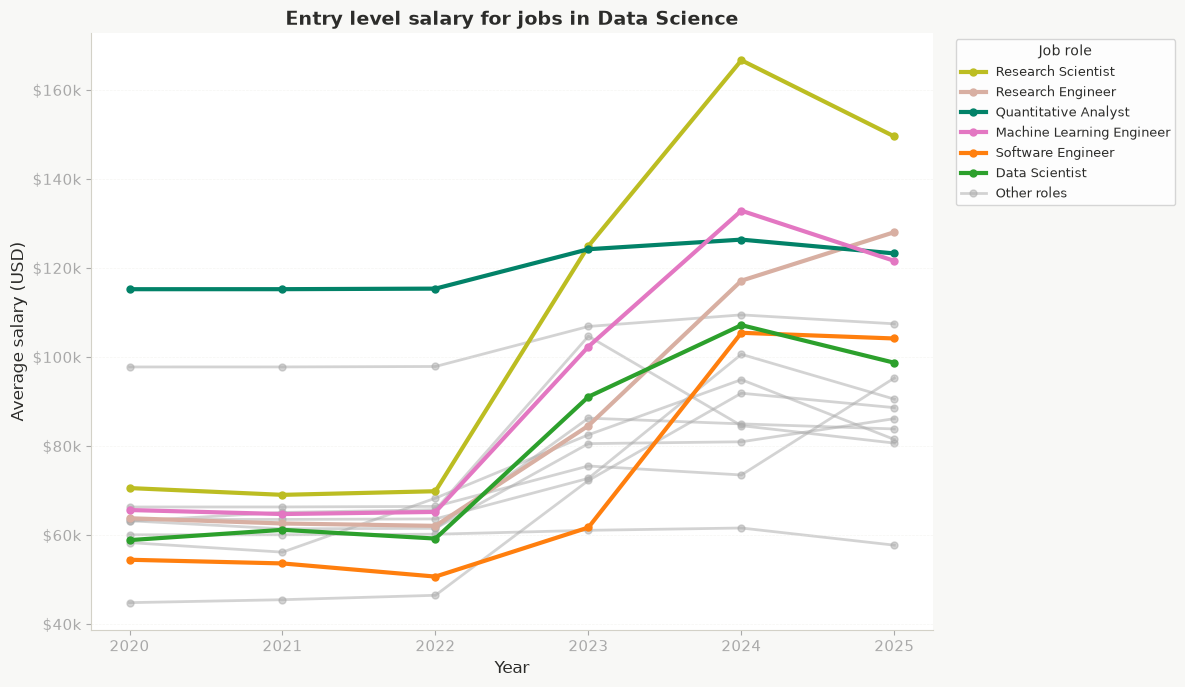

In [78]:
plot_entry_level_salary_trends(full_df, save_path=ALT_FIGURE_SAVE_PATH, highlighted_roles=target_roles)

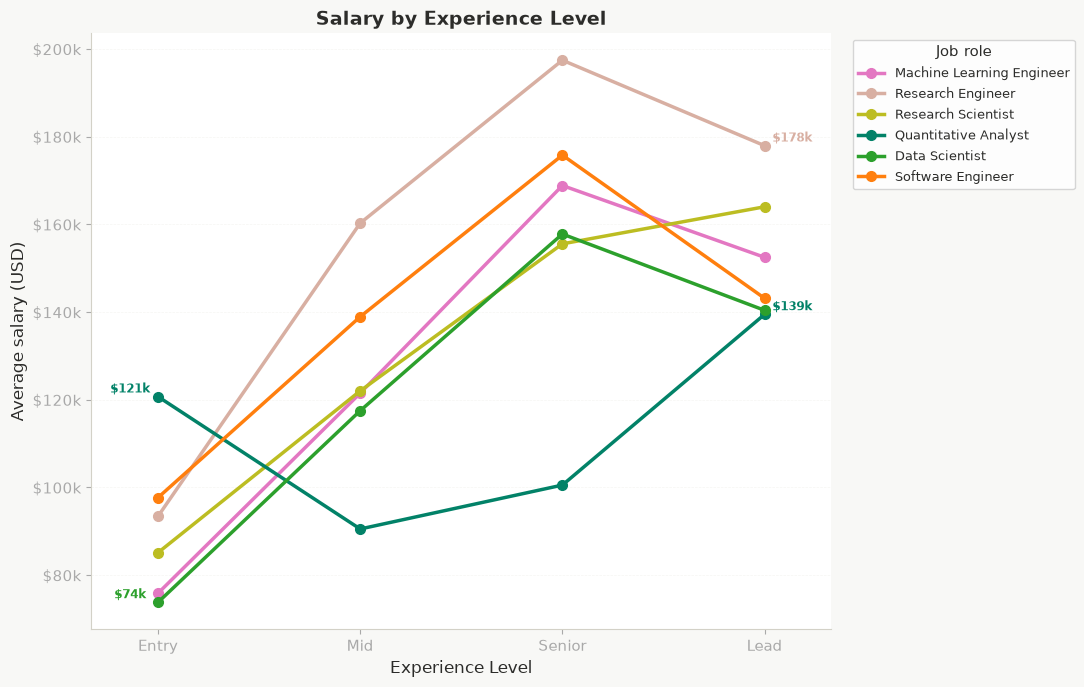

In [79]:
plot_salary_by_experience_level(
    full_df,
    target_roles=target_roles,
    save_path=ALT_FIGURE_SAVE_PATH
)

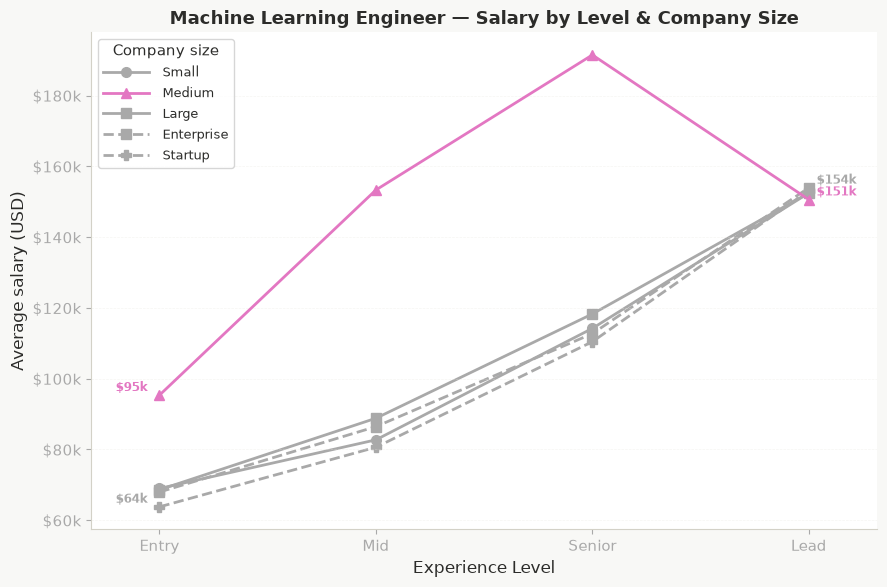

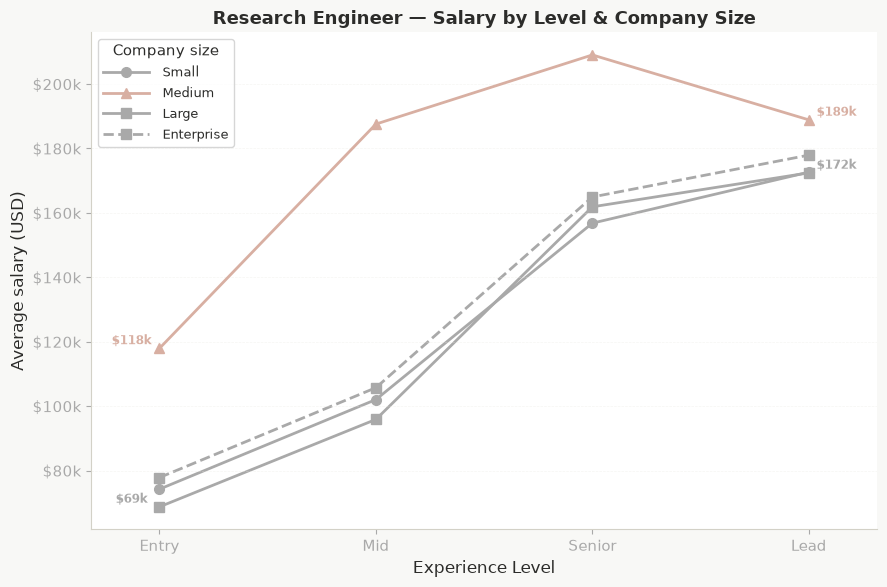

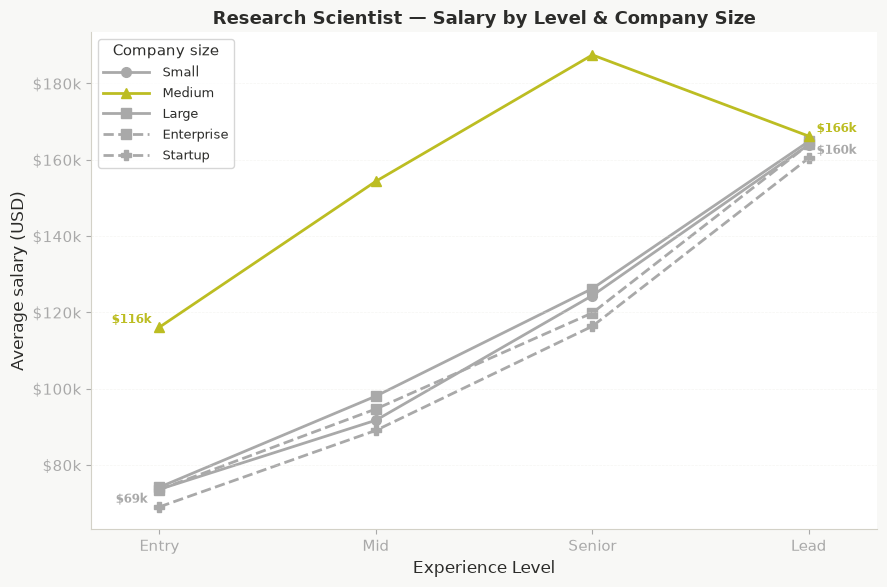

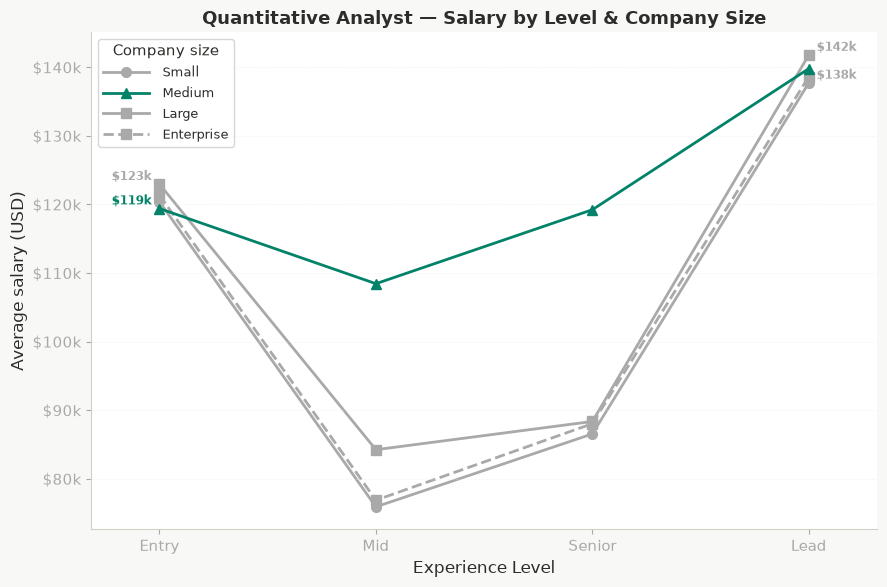

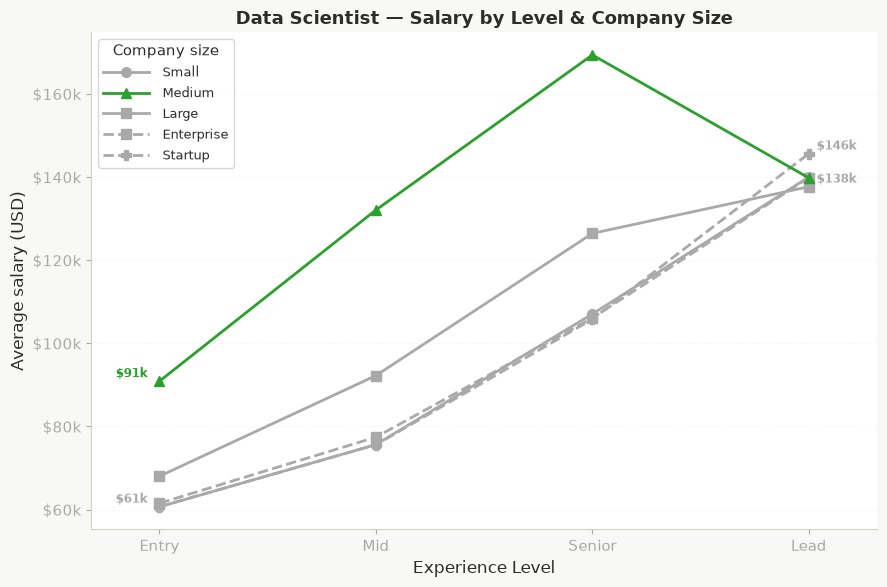

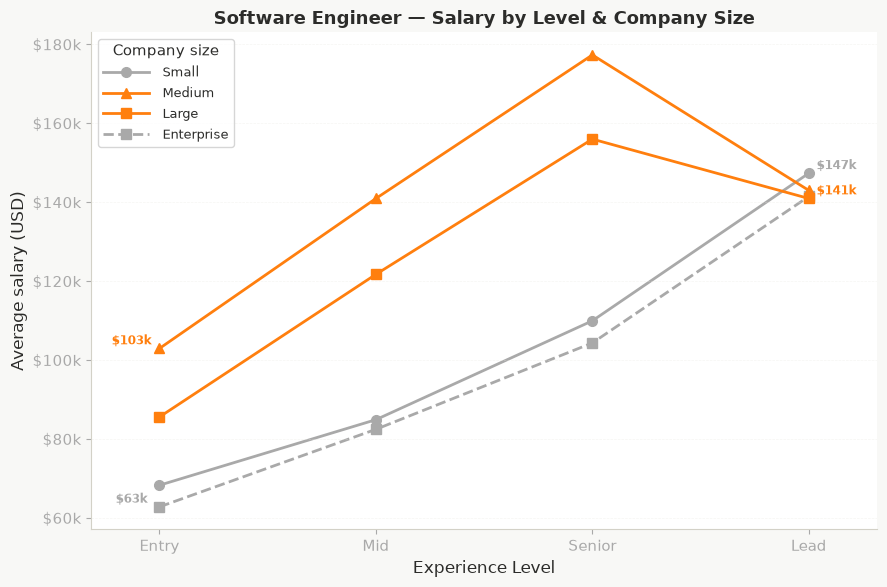

In [80]:
plot_role_salary_by_level_and_company_size(
    full_df,
    target_roles=target_roles,
    save_path=ALT_FIGURE_SAVE_PATH,
    highlighted_role_sizes={
        "Data Scientist": ["Medium"],
        "Machine Learning Engineer": ["Medium"],
        "Research Engineer": ["Medium"],
        "Software Engineer": ["Medium", "Large"],
        "Research Scientist": ["Medium"],
        "Quantitative Analyst": ["Medium"]
    }
)

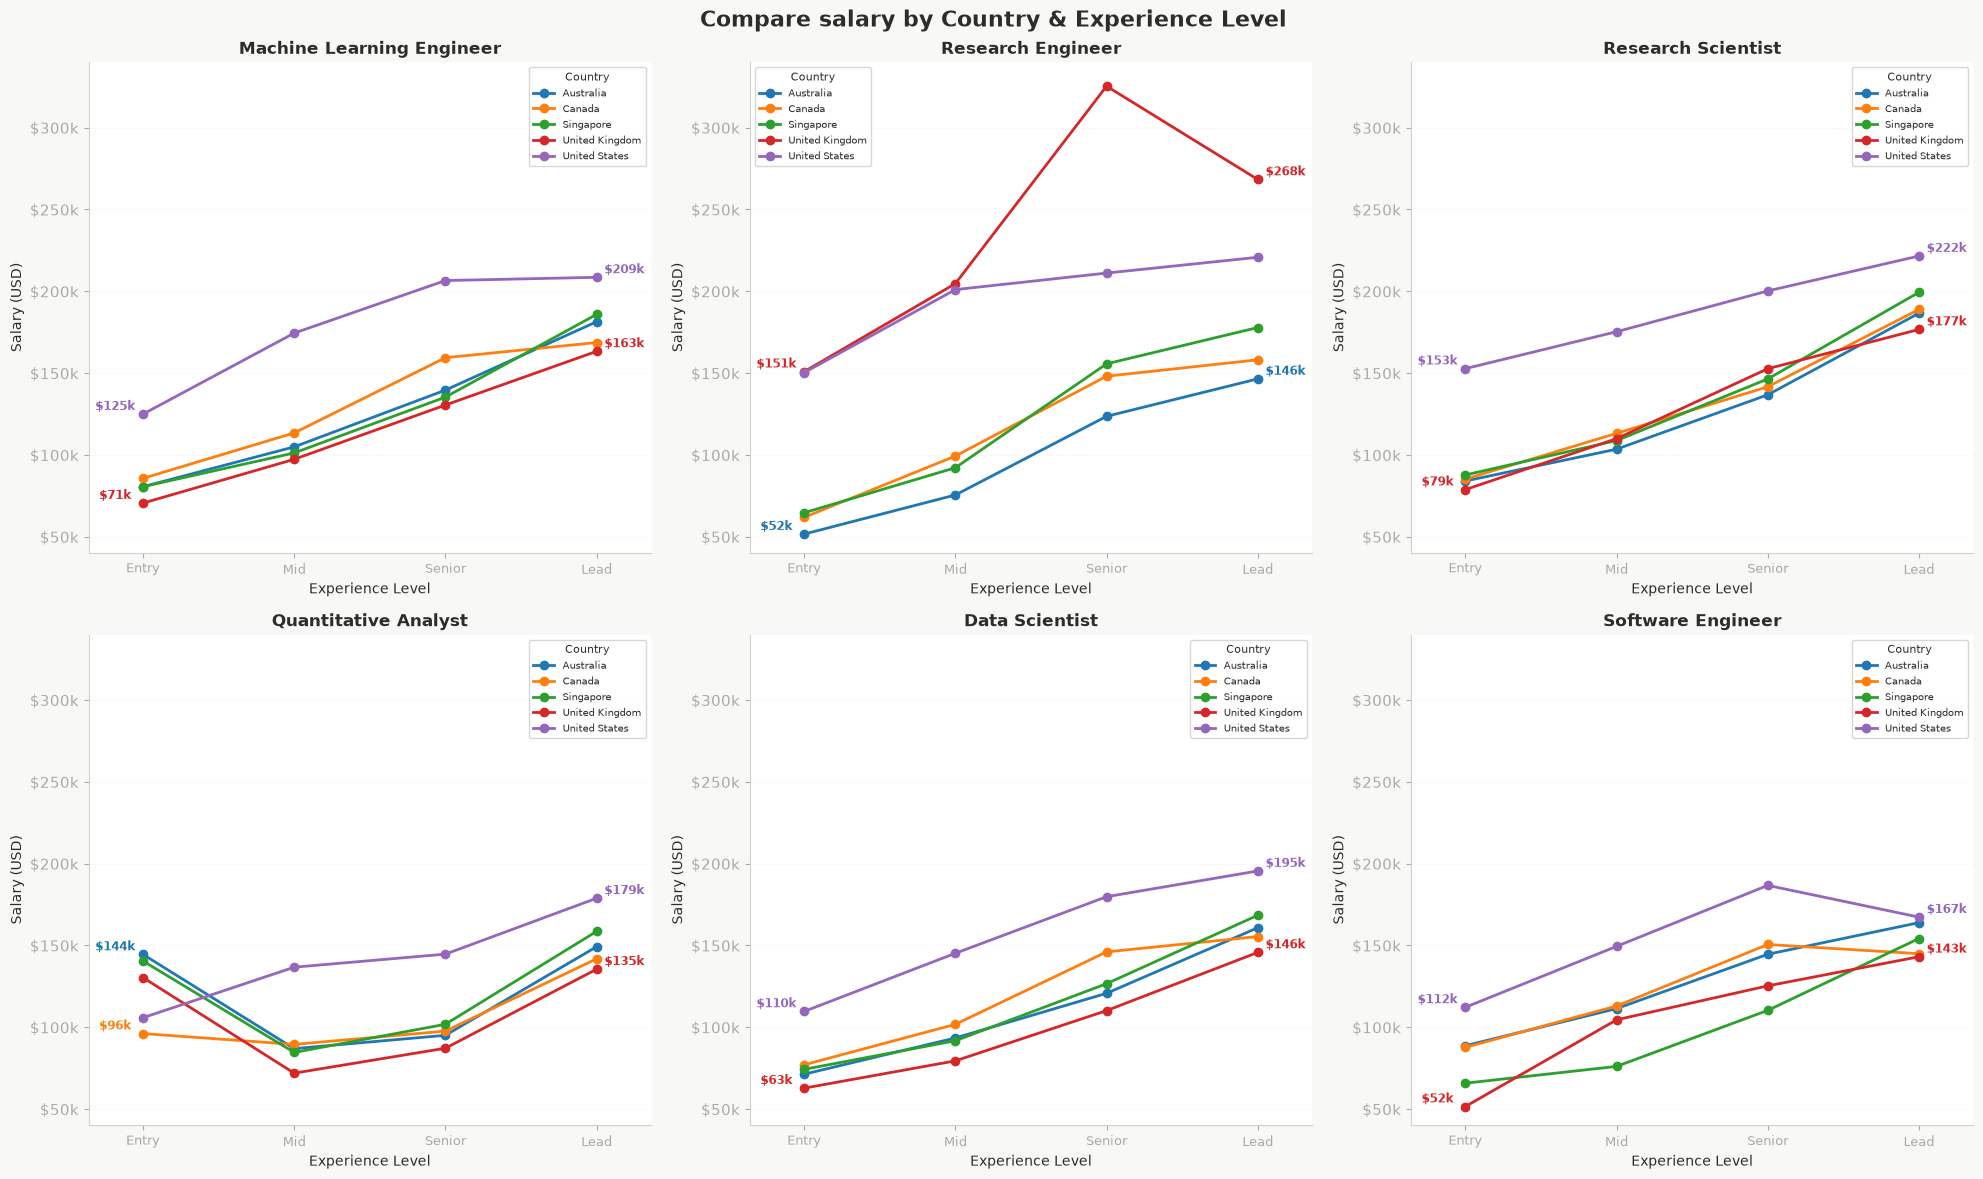

In [81]:
SELECTED_COUNTRIES = [
    "Canada",
    "United States",
    "Singapore",
    "United Kingdom",
    "Australia"
]

plot_salary_by_country_and_level(
    full_df,
    countries=SELECTED_COUNTRIES,
    target_roles=target_roles,
    save_path=ALT_FIGURE_SAVE_PATH,
    ylim=(40000, 340000)
)

In [82]:
if "google.colab" in str(get_ipython()):
    !zip -r plots.zip {ALT_FIGURE_SAVE_PATH}